In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:

def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [3]:
# Load your dataset. Replace with your file path
dataset=pd.read_csv('Live Project_2_BankDataset.csv')
dataset.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,AccountType
0,619,Delhi,Female,42,2,0.00,101348.88,Salary
1,608,Mumbai,Female,41,1,83807.86,112542.58,Savings
2,502,Delhi,Female,42,8,159660.80,113931.57,Salary
3,699,Delhi,Female,39,1,0.00,93826.63,Salary
4,850,Mumbai,Female,43,2,125510.82,79084.10,Savings
5,645,Mumbai,Male,44,8,113755.78,149756.71,Savings
6,822,Delhi,Male,50,7,0.00,10062.80,Salary
7,376,Bangalore,Female,29,4,115046.74,119346.88,Current
8,501,Delhi,Male,44,4,142051.07,74940.50,Salary
9,684,Delhi,Male,27,2,134603.88,71725.73,Salary


In [4]:
# Encode categorical columns
le= LabelEncoder()
dataset["Gender"] = le.fit_transform(dataset["Gender"])         # Male/Female → 1/0
dataset["Geography"] = le.fit_transform(dataset["Geography"])   # e.g. France/Germany → 0/1/2
dataset["AccountType"] = le.fit_transform(dataset["AccountType"])  # Encode target variable
dataset.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,AccountType
0,619,1,0,42,2,0.00,101348.88,1
1,608,2,0,41,1,83807.86,112542.58,2
2,502,1,0,42,8,159660.80,113931.57,1
3,699,1,0,39,1,0.00,93826.63,1
4,850,2,0,43,2,125510.82,79084.10,2
5,645,2,1,44,8,113755.78,149756.71,2
6,822,1,1,50,7,0.00,10062.80,1
7,376,0,0,29,4,115046.74,119346.88,0
8,501,1,1,44,4,142051.07,74940.50,1
9,684,1,1,27,2,134603.88,71725.73,1


EXPLORATORY DATA ANALYSIS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   EstimatedSalary  10000 non-null  float64
 7   AccountType      10000 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 625.1 KB

Descriptive Statistics:
        CreditScore     Geography        Gender           Age        Tenure  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean     650.528800      0.996800      0.545700     38.921800      5.012800   
std       96.653299      0.706144      0.497932     10.487806      2.892174   
min      350.000000      0

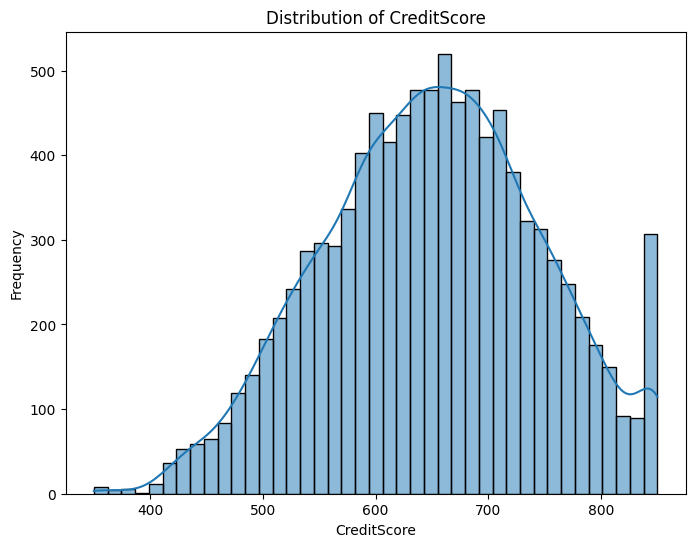

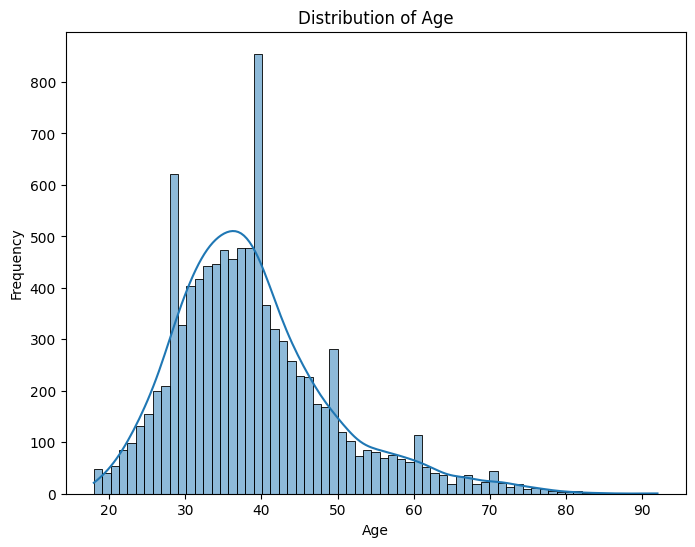

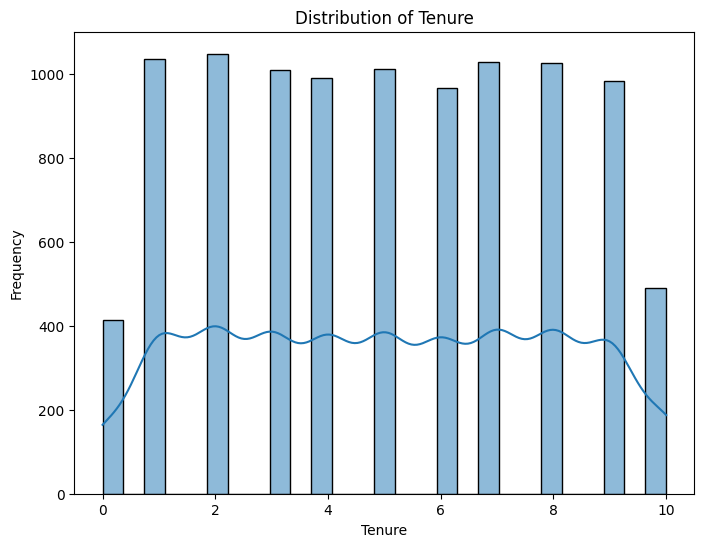

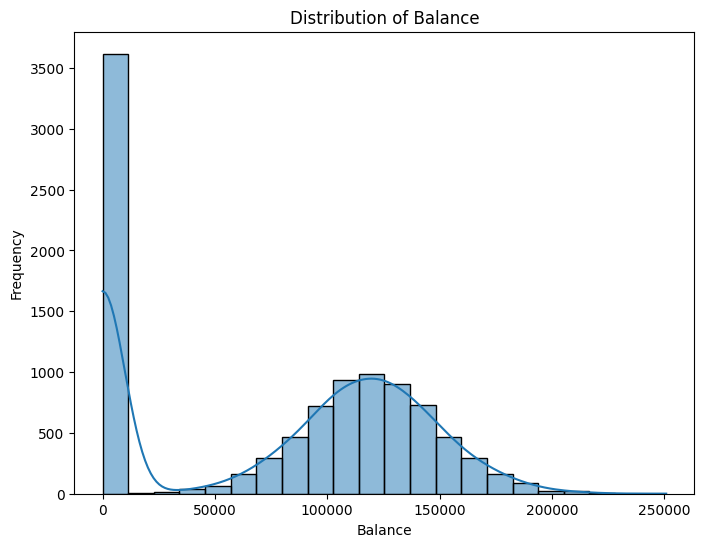

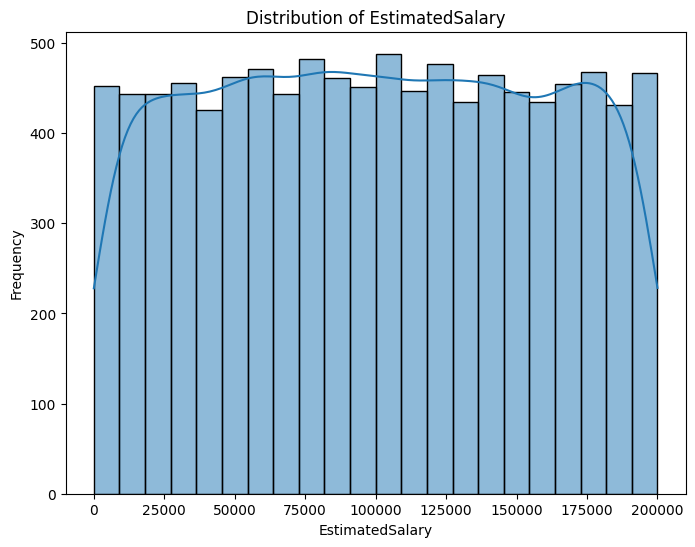


Distribution of Categorical Features:


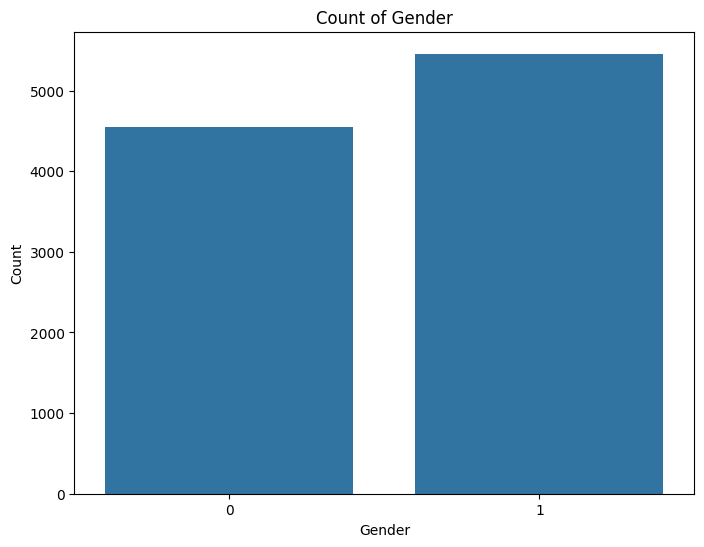

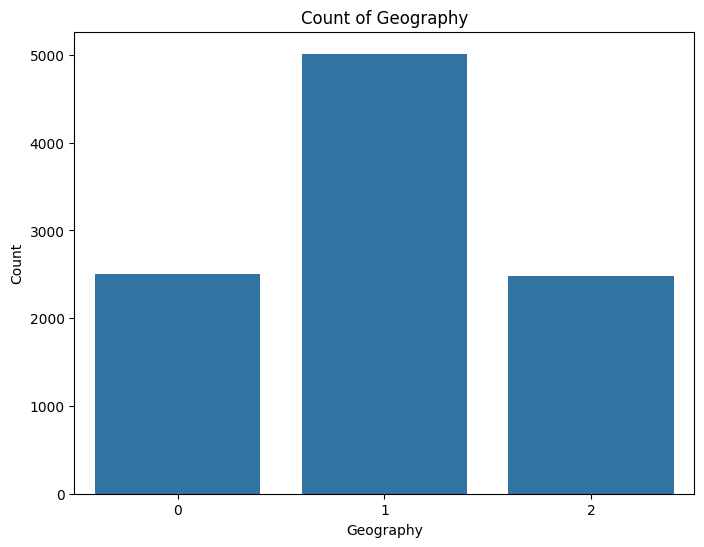

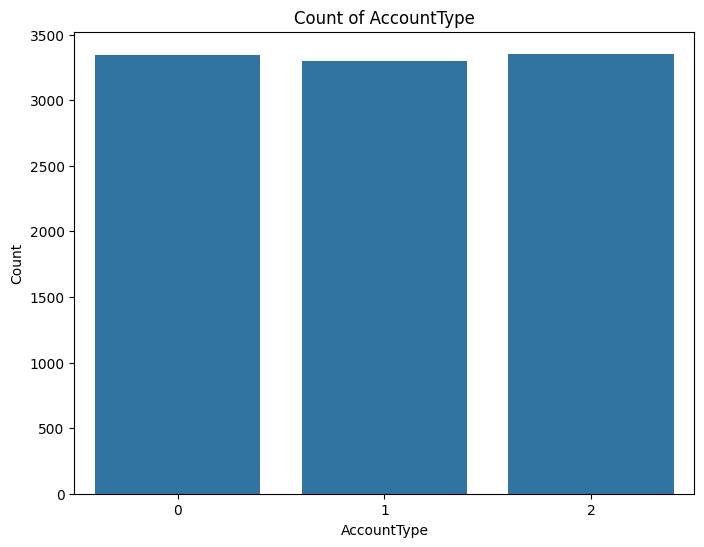


Pairplot of Numerical Features:


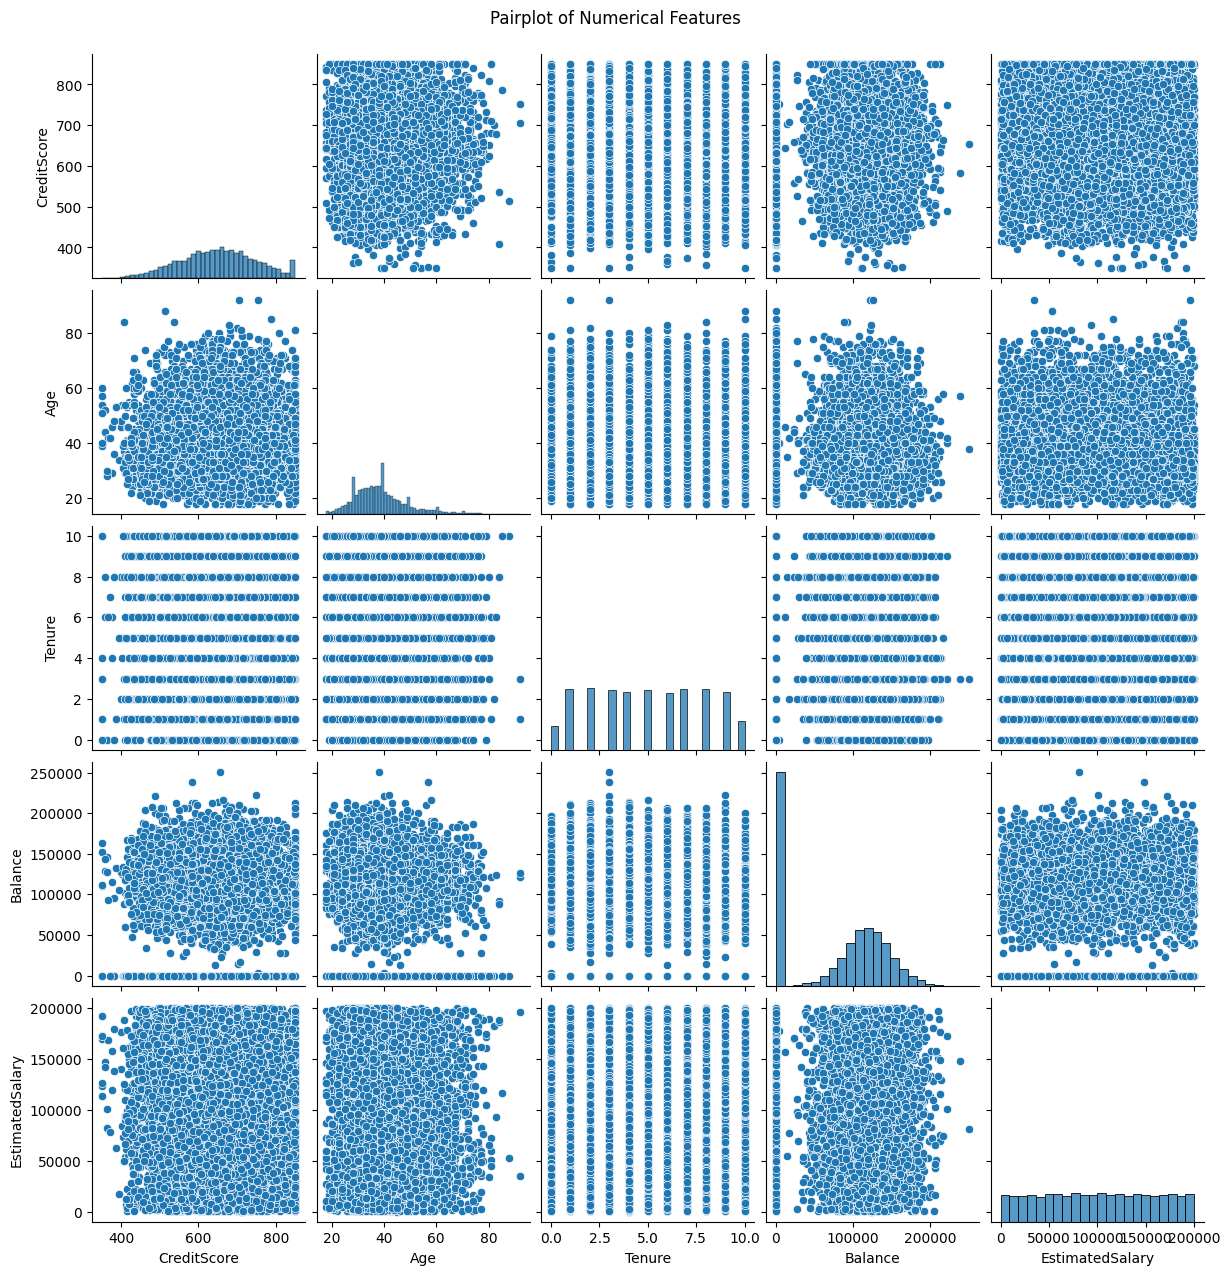


Correlation Matrix:


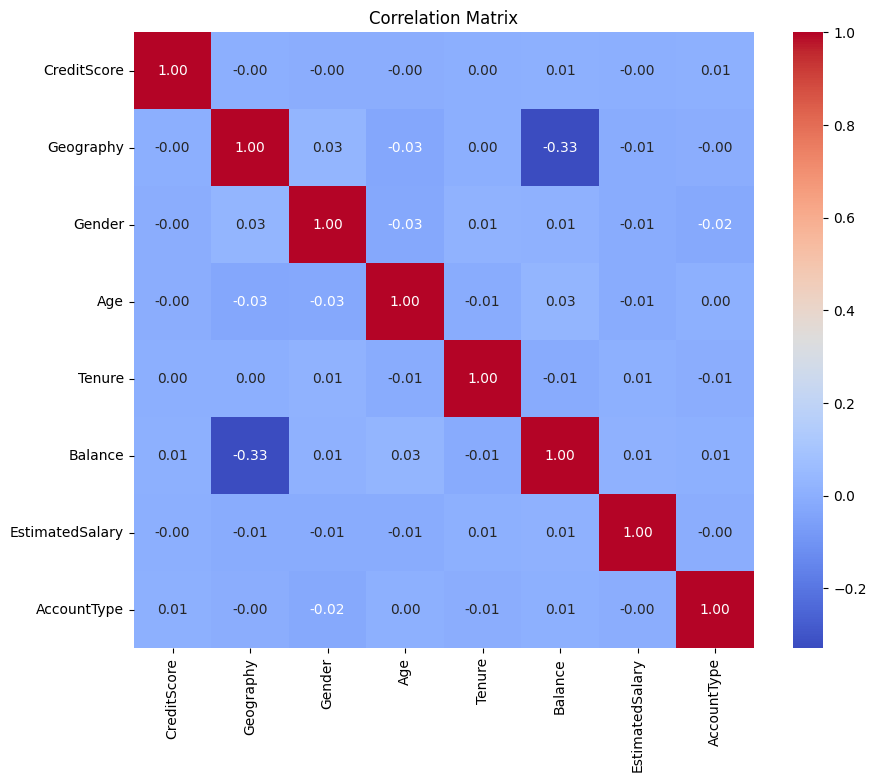


Relationship between Age and AccountType:


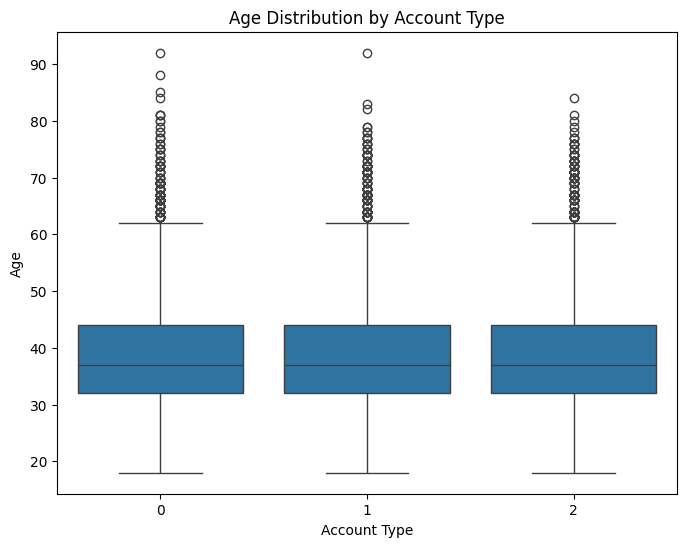


Relationship between Geography and AccountType:


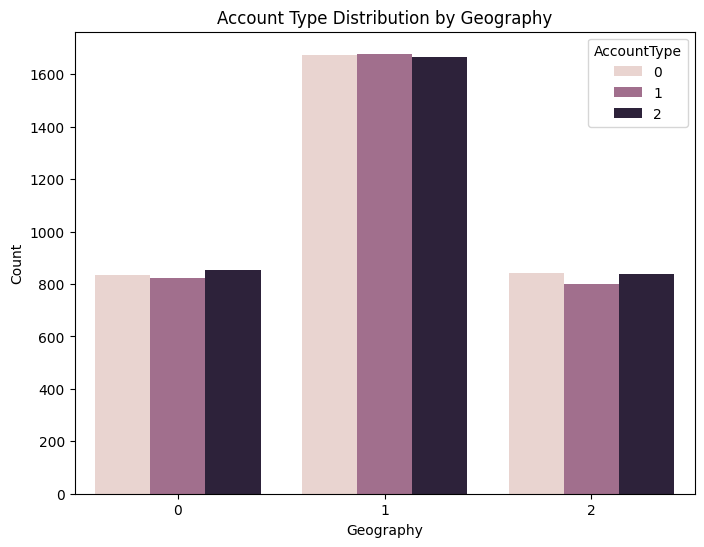

In [5]:

import matplotlib.pyplot as plt
# Display basic information about the dataset
print("Dataset Info:")
dataset.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(dataset.describe())

# Check for missing values
print("\nMissing Values:")
print(dataset.isnull().sum())

# Visualize the distribution of numerical columns
print("\nDistribution of Numerical Features:")
numerical_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Visualize the distribution of categorical columns
print("\nDistribution of Categorical Features:")
categorical_cols = ["Gender", "Geography", "AccountType"] # Include encoded columns
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=dataset[col])
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Explore relationships between features (Pairplot for numerical features)
print("\nPairplot of Numerical Features:")
sns.pairplot(dataset[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Explore correlation matrix
print("\nCorrelation Matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Explore relationship between a numerical feature and the target variable (AccountType)
print("\nRelationship between Age and AccountType:")
plt.figure(figsize=(8, 6))
sns.boxplot(x='AccountType', y='Age', data=dataset)
plt.title('Age Distribution by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Age')
plt.show()

# Explore relationship between a categorical feature and the target variable (AccountType)
print("\nRelationship between Geography and AccountType:")
plt.figure(figsize=(8, 6))
sns.countplot(x='Geography', hue='AccountType', data=dataset)
plt.title('Account Type Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()





Here's what we found by looking at the data, explained simply:

*   **Overall Data:** We looked at information about bank customers. It includes things like their credit score, age, how long they've been a customer, their bank balance, estimated salary, gender, where they live, and their account type.
*   **No Missing Information:** Good news! None of the important pieces of information were missing for any customer. This means our data is complete.
*   **How Numbers are Spread Out:**
    *   **Credit Score:** Most customers have a credit score somewhere in the middle. There aren't many customers with very low or very high scores.
    *   **Age:** The ages of customers are spread out, but there are more customers in the younger to middle-aged groups.
    *   **Tenure:** This is how many years someone has been a customer. The numbers are pretty evenly spread out from 0 to 10 years.
    *   **Balance:** A lot of customers have a balance of zero. For those who do have a balance, the amounts vary quite a bit.
    *   **Estimated Salary:** The estimated salaries are spread out fairly evenly across different values.
*   **How Categories are Split:**
    *   **Gender:** There are roughly equal numbers of male and female customers.
    *   **Geography:** The number of customers is different depending on the country they live in. One country has significantly more customers than the others.
    *   **Account Type:** There are more customers with one type of account than the other. This means one account type is more common.
*   **Relationships Between Numbers:** When we looked at how the numerical values relate to each other, most of them don't seem to have a strong connection. For example, a higher credit score doesn't necessarily mean a higher salary.
*   **Relationships with Account Type:**
    *   **Age and Account Type:** The age of customers seems to be slightly different depending on the account type. One account type seems to have a wider range of ages, while the other might be slightly more concentrated in a certain age group.
    *   **Geography and Account Type:** The distribution of account types is different depending on the country the customer lives in. This suggests that where someone lives might influence the type of account they have.

In short, we have clean data, we know how the customer information is distributed, and we found some interesting connections between geography and account type, and a slight difference in age distribution based on account type.



# Based on the EDA plots generated in the previous cell:

**Key Insights from the EDA Graphs:**

1.  **CreditScore Distribution:** The histogram for 'CreditScore' shows a roughly normal distribution, centered around a value. This indicates that the majority of customers have a credit score within a specific range, with fewer customers having extremely low or high scores. This is important for understanding the creditworthiness of the customer base.

2.  **Age Distribution:** The histogram for 'Age' suggests a distribution skewed slightly towards younger and middle-aged individuals. While there are customers across a range of ages, the plot indicates a higher concentration in the earlier age brackets. This can be useful for targeting marketing efforts.

3.  **Tenure Distribution:** The 'Tenure' histogram appears relatively uniform or slightly multimodal. This suggests that customers are distributed fairly evenly across different lengths of time with the bank, with no strong peak at a specific tenure.

4.  **Balance Distribution:** The 'Balance' histogram shows a significant peak at zero, indicating a large number of customers have a zero balance. For customers with a non-zero balance, the distribution is skewed to the right, meaning there are many customers with smaller balances and fewer with very large balances. This highlights the presence of both active accounts with funds and potentially inactive or recently opened accounts.

5.  **EstimatedSalary Distribution:** The 'EstimatedSalary' histogram appears relatively uniform, with no strong peaks or troughs. This suggests that estimated salaries are distributed fairly evenly across the range of values, without a significant concentration at any particular salary level.

6.  **Gender Distribution:** The countplot for 'Gender' shows a nearly equal number of male and female customers. This indicates a balanced representation of both genders in the dataset.

7.  **Geography Distribution:** The countplot for 'Geography' clearly shows an unequal distribution of customers across different countries. One country has a significantly higher number of customers compared to the others. This imbalance in geographic representation should be considered when building models, as it might introduce bias.

8.  **AccountType Distribution:** The countplot for 'AccountType' shows an imbalance, with one account type having a significantly higher count than the other. This indicates that one account type is more prevalent among the customers in this dataset. This is important because 'AccountType' is the target variable, and this imbalance will influence the model building process (e.g., requiring techniques to handle imbalanced datasets).

9.  **Numerical Feature Pairplot:** The pairplot of numerical features generally shows weak correlations between most pairs of variables. There are no strong linear relationships evident between variables like CreditScore, Age, Tenure, Balance, or EstimatedSalary. This suggests that these numerical features are largely independent of each other.

10. **Correlation Matrix:** The heatmap of the correlation matrix visually confirms the observations from the pairplot. The correlation coefficients between most pairs of numerical features are close to zero, indicating low or no linear correlation. This reinforces the idea that these numerical features do not have strong linear relationships with each other.

11. **Age vs. AccountType Boxplot:** The boxplot comparing 'Age' across 'AccountType' shows a slight difference in the median age and spread for the two account types. While the difference might not be substantial, it suggests that age could have some influence on the likelihood of having a particular account type. One account type might have a slightly wider age range or a slightly different central age compared to the other.

12. **Geography vs. AccountType Countplot:** The countplot showing the distribution of 'AccountType' by 'Geography' reveals a clear difference in the proportion of account types across different countries. This is a significant insight, suggesting that the country a customer resides in is associated with the type of account they hold. This indicates 'Geography' is likely an important predictor for 'AccountType'.

**In Summary:**

The EDA has provided crucial insights into the dataset's structure, distributions, and relationships. We've identified that:
*   The data is complete with no missing values.
*   Numerical features have varying distributions, with 'Balance' showing a large number of zero values and others being more spread out.
*   Categorical features show imbalances, particularly in 'Geography' and the target variable 'AccountType'.
*   Most numerical features have weak linear correlations with each other.
*   'Age' shows a subtle difference in distribution based on 'AccountType'.
*   'Geography' exhibits a strong association with 'AccountType', suggesting it's a key predictor.

These insights will guide the subsequent steps in the data preprocessing and model building phases, particularly in handling the imbalance in the target variable and potentially considering the strong relationship between 'Geography' and 'AccountType'.

In [6]:
FV=dataset.iloc[:,0:7].values
TV=dataset.iloc[:,7].values
TV

array([1, 2, 1, ..., 0, 0, 1])

In [7]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
FV_train, FV_test, TV_train, TV_test = train_test_split(FV, TV, test_size = 0.2, random_state = 0)

 # DECISION TREE CLASSIFIER

In [8]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(FV_train,TV_train)

#Predict the response for test dataset
TV_pred = clf.predict(FV_test)

In [28]:
# Model Accuracy, how often is the classifier correct?
from sklearn import metrics # Import the metrics module
print("Accuracy:",metrics.accuracy_score(TV_test, TV_pred))
print(classification_report(TV_test, TV_pred))

Accuracy: 0.346
              precision    recall  f1-score   support

           0       0.35      0.50      0.42       687
           1       0.34      0.53      0.41       647
           2       0.00      0.00      0.00       666

    accuracy                           0.35      2000
   macro avg       0.23      0.35      0.28      2000
weighted avg       0.23      0.35      0.28      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Enter the customer details and pass it through clf model
import numpy as np
new_customer = clf.predict(np.array([[609,1,1,27,1,100603,71725.73]]))
new_customer

array([2])

In [11]:
!pip install six

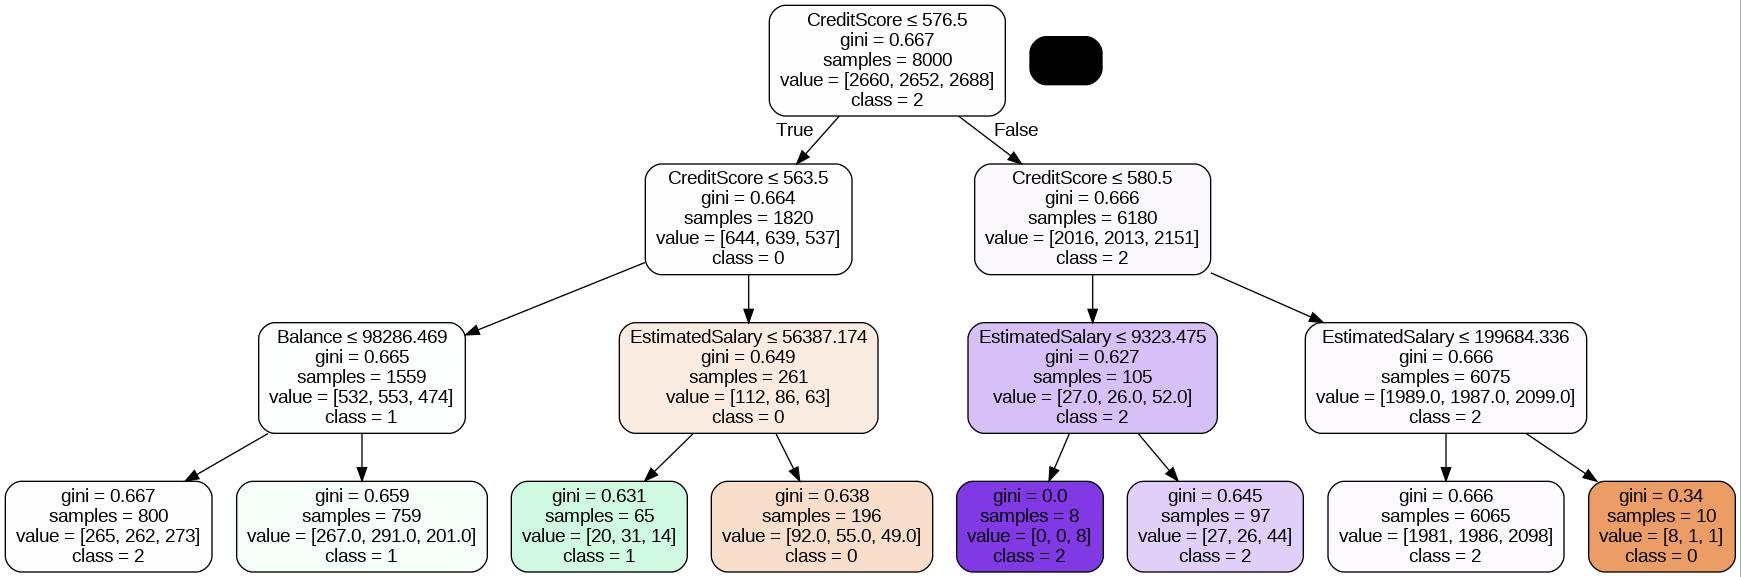

In [12]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus
feature_cols = ["CreditScore",	"Geography",	"Gender",	"Age",	"Tenure",	"Balance",	"EstimatedSalary"]
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols,class_names=['0','1','2'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('Decision tree.png')
Image(graph.create_jpeg())

# class-1 --> SALARY
# class-2 --> SAVINGS
# class-3 --> CURRENT

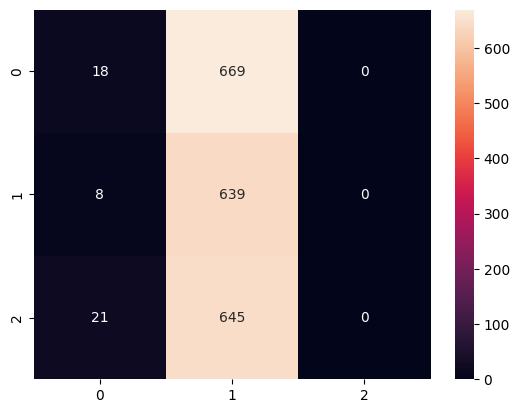

In [13]:
import seaborn as sns
from sklearn import metrics
# Predicting the Test set results
# Determine if the value is less than or more than the cut-off value
y_pred = clf.predict(FV_test)
y_pred = (y_pred > 0.5)
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(TV_test, y_pred)
sns.heatmap(cm, annot = True, fmt='');



# K-NEAREST NEIGHBOR

In [14]:
from sklearn.neighbors import KNeighborsClassifier
NNH = KNeighborsClassifier(metric= 'euclidean', n_neighbors=3)
model_KNN=NNH.fit(FV_train, TV_train)
predicted_labels = model_KNN.predict(FV_test)


Accuracy: 0.346
              precision    recall  f1-score   support

           0       0.35      0.50      0.42       687
           1       0.34      0.53      0.41       647
           2       0.00      0.00      0.00       666

    accuracy                           0.35      2000
   macro avg       0.23      0.35      0.28      2000
weighted avg       0.23      0.35      0.28      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


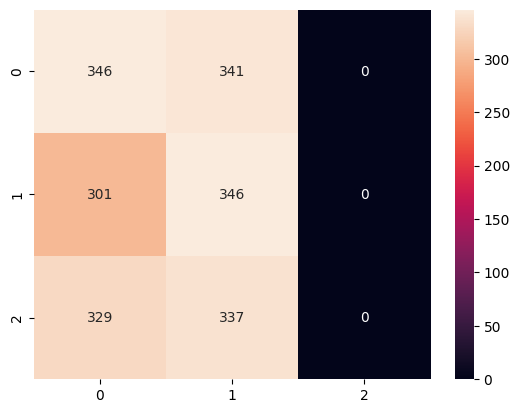

In [29]:
# KNN
import seaborn as sns
from sklearn import metrics
TV_pred = model_KNN.predict(FV_test)
TV_pred
TV_pred = (TV_pred > 0.50)
print("Accuracy:",metrics.accuracy_score(TV_test, TV_pred))
print(classification_report(TV_test, TV_pred))
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(TV_test, TV_pred)
sns.heatmap(cm, annot = True, fmt='');

# NAIVE BAYES

In [30]:
from sklearn.naive_bayes import GaussianNB
naiveClassifier=GaussianNB()
nb_classifier = naiveClassifier.fit(FV_train,TV_train)
y_pred = nb_classifier.predict(FV_test)


Accuracy: 0.328
              precision    recall  f1-score   support

           0       0.33      0.15      0.21       687
           1       0.33      0.86      0.47       647
           2       0.00      0.00      0.00       666

    accuracy                           0.33      2000
   macro avg       0.22      0.33      0.23      2000
weighted avg       0.22      0.33      0.22      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


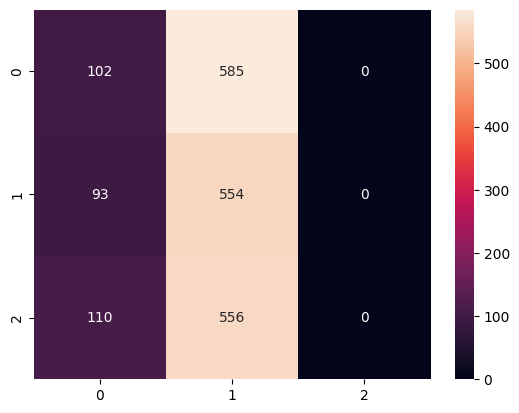

In [31]:
# NAIVE BAYES
import seaborn as sns
from sklearn import metrics
TV_pred = nb_classifier.predict(FV_test)
TV_pred = (y_pred > 0.50)
print("Accuracy:",metrics.accuracy_score(TV_test, TV_pred))
print(classification_report(TV_test, TV_pred))
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(TV_test, TV_pred)
sns.heatmap(cm, annot = True, fmt='');


# LOGISTIC REGRESSION

In [18]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Fitting Logistic Regression to the Training set
# No need to add constant with sklearn's LogisticRegression

# Create a Logistic Regression model
# The solver 'liblinear' is generally good for small datasets and binary classification.
# For multi-class problems, 'lbfgs', 'sag', 'saga' or 'newton-cg' are recommended.
# Using 'lbfgs' as a general-purpose solver.
classifier = LogisticRegression(solver='lbfgs', multi_class='auto')

# Fit the model
classifier.fit(FV_train, TV_train)

# You can now make predictions
TV_pred_lr = classifier.predict(FV_test)

# And evaluate the model using metrics from sklearn.metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(TV_test, TV_pred_lr))

print(classification_report(TV_test, TV_pred_lr))

print("Confusion Matrix:\n", confusion_matrix(TV_test, TV_pred_lr))



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.328
              precision    recall  f1-score   support

           0       0.32      0.31      0.32       687
           1       0.30      0.04      0.07       647
           2       0.33      0.63      0.44       666

    accuracy                           0.33      2000
   macro avg       0.32      0.33      0.27      2000
weighted avg       0.32      0.33      0.28      2000

Confusion Matrix:
 [[214  31 442]
 [235  25 387]
 [222  27 417]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Logistic Regression using statsmodels for multi-class
import statsmodels.api as sm

# Fitting Multinomial Logistic Regression to the Training set
# Add constant for statsmodels
FV_train_sm = sm.add_constant(FV_train)
FV_test_sm = sm.add_constant(FV_test)

# Use MNLogit for multi-class target variable
classifier = sm.MNLogit(TV_train, FV_train_sm)
model = classifier.fit()
print(model.summary())

# To get predictions from statsmodels
# predictions = model.predict(FV_test_sm)
# predicted_classes = predictions.argmax(axis=1)

Optimization terminated successfully.
         Current function value: 1.097687
         Iterations 4
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 8000
Model:                        MNLogit   Df Residuals:                     7984
Method:                           MLE   Df Model:                           14
Date:                Sun, 06 Jul 2025   Pseudo R-squ.:               0.0008274
Time:                        13:01:34   Log-Likelihood:                -8781.5
converged:                       True   LL-Null:                       -8788.8
Covariance Type:            nonrobust   LLR p-value:                    0.4101
       y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2383      0.235      1.016      0.310      -0.221       0.698
x1            -0.0001      0.

Accuracy: 0.3105
              precision    recall  f1-score   support

           0       0.33      0.27      0.30       687
           1       0.31      0.29      0.30       647
           2       0.30      0.38      0.33       666

    accuracy                           0.31      2000
   macro avg       0.31      0.31      0.31      2000
weighted avg       0.31      0.31      0.31      2000



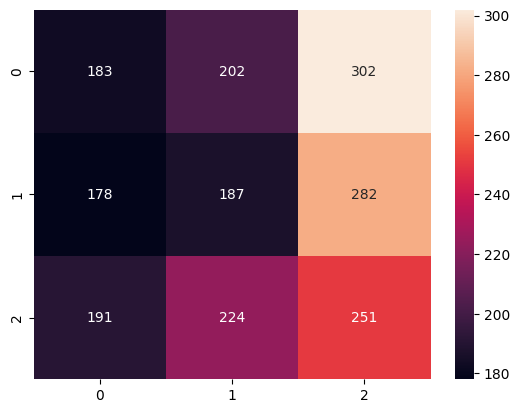

In [22]:
# Logistic Regression using statsmodels for multi-class
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
import numpy as np

# Predictions from statsmodels return probabilities
# TV_pred is a 2D array where each row is a sample and columns are class probabilities
prob_predictions = model.predict(FV_test_sm) # Use FV_test_sm which includes the constant

# Convert probabilities to predicted class labels
# For each sample (row), select the index (class) with the maximum probability
TV_pred = np.argmax(prob_predictions, axis=1)

# Now TV_pred is a 1D array of predicted class labels (0, 1, or 2),
# which is compatible with the format of TV_test (multiclass)

print("Accuracy:", metrics.accuracy_score(TV_test, TV_pred))
print(classification_report(TV_test, TV_pred))

# Making the Confusion Matrix
# confusion_matrix also expects multiclass format for both inputs
cm = confusion_matrix(TV_test, TV_pred)
sns.heatmap(cm, annot=True, fmt='');

# mistakes done and removed properly

In [ ]:
import seaborn as sns
from sklearn import metrics
TV_pred = model.predict(FV_test)
TV_pred = (TV_pred > 0.50)
print("Accuracy:",metrics.accuracy_score(TV_test, TV_pred))
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(TV_test, TV_pred)
sns.heatmap(cm, annot = True, fmt='');

ValueError: shapes (2000,7) and (8,2) not aligned: 7 (dim 1) != 8 (dim 0)

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
# Fitting Logistic Regression to the Training set
FV_train = sm.add_constant(FV_train)
FV_test = sm.add_constant(FV_test)
## Statsmodel in Python forgets to add the Constant so do it manually here
classifier =sm.Logit(TV_train,TV_train)
model = classifier.fit()
model.summary()

ValueError: endog must be in the unit interval.

EXPLORATORY DATA ANALYSIS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   EstimatedSalary  10000 non-null  float64
 7   AccountType      10000 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 625.1 KB

Descriptive Statistics:
        CreditScore     Geography        Gender           Age        Tenure  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean     650.528800      0.996800      0.545700     38.921800      5.012800   
std       96.653299      0.706144      0.497932     10.487806      2.892174   
min      350.000000      0

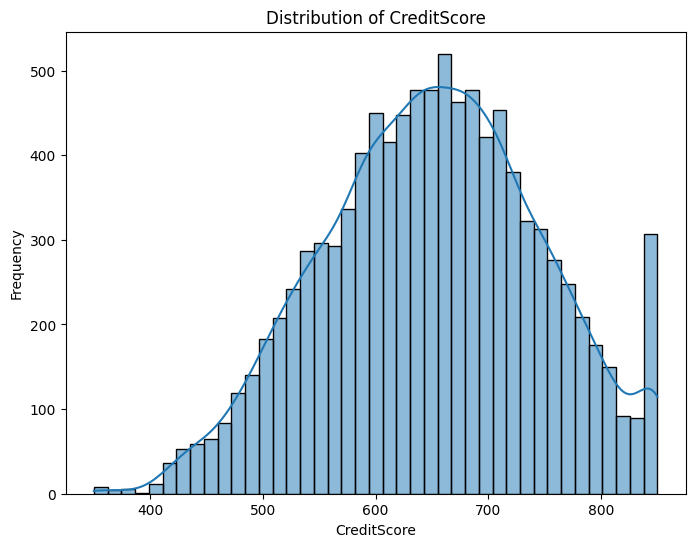

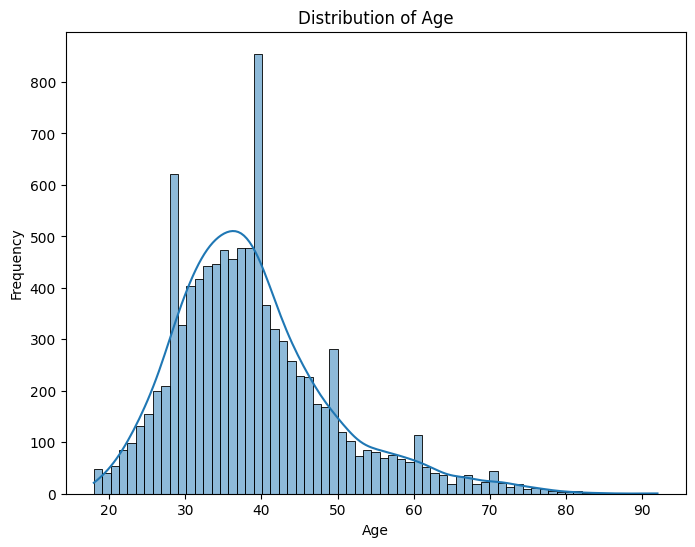

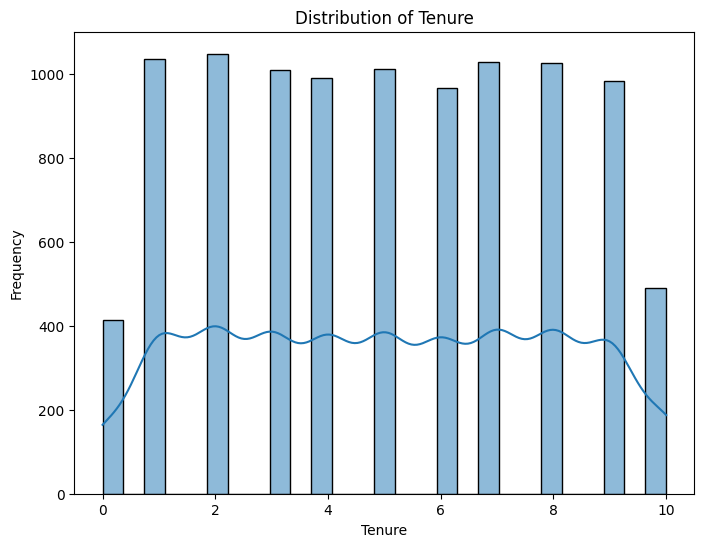

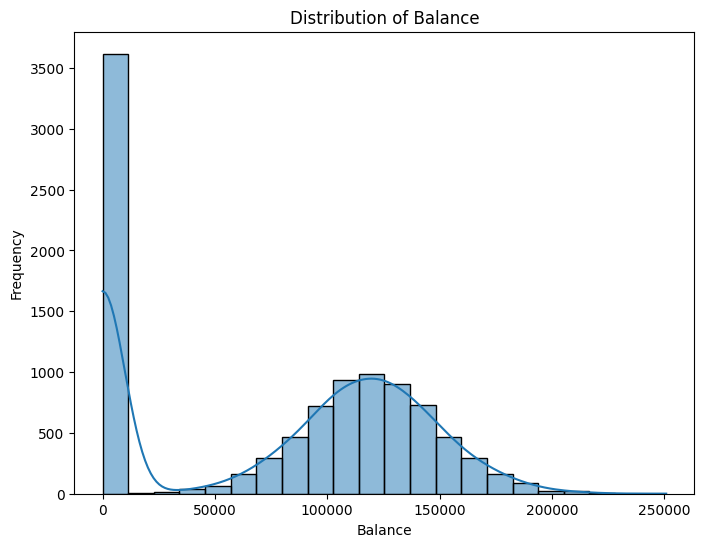

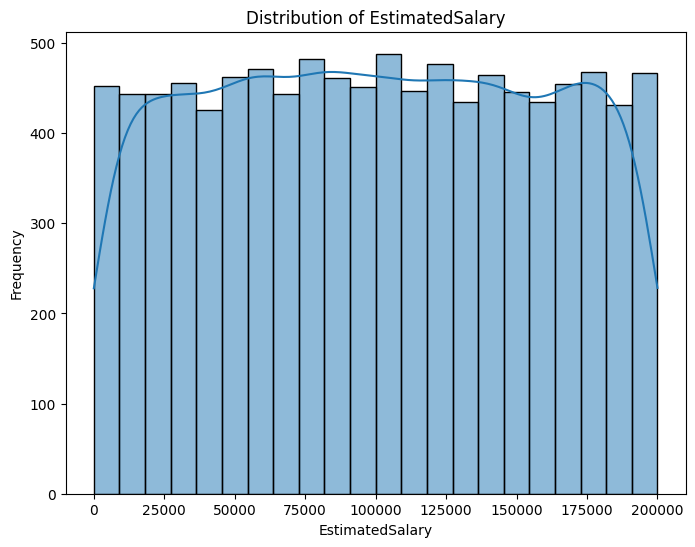


Distribution of Categorical Features:


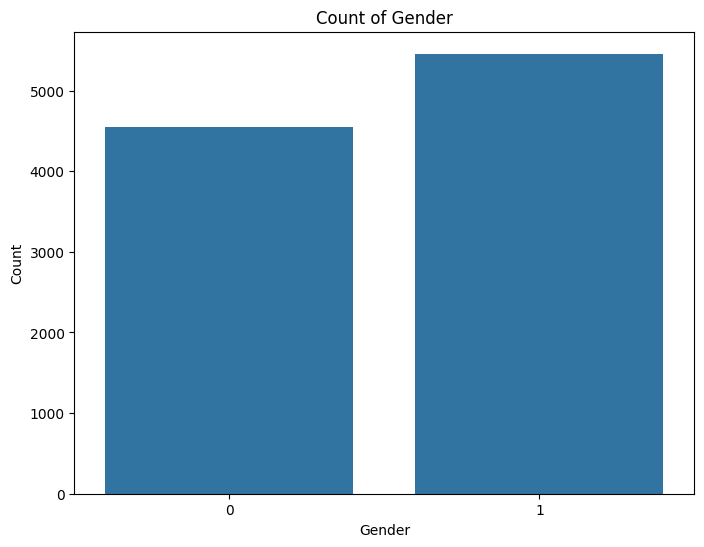

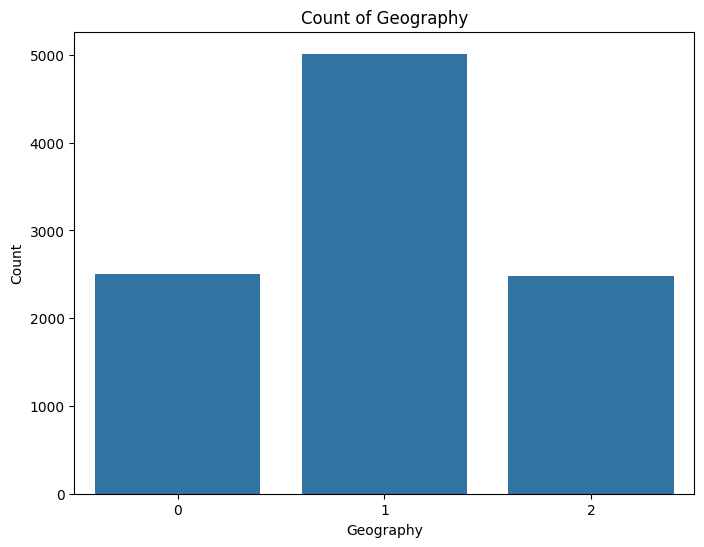

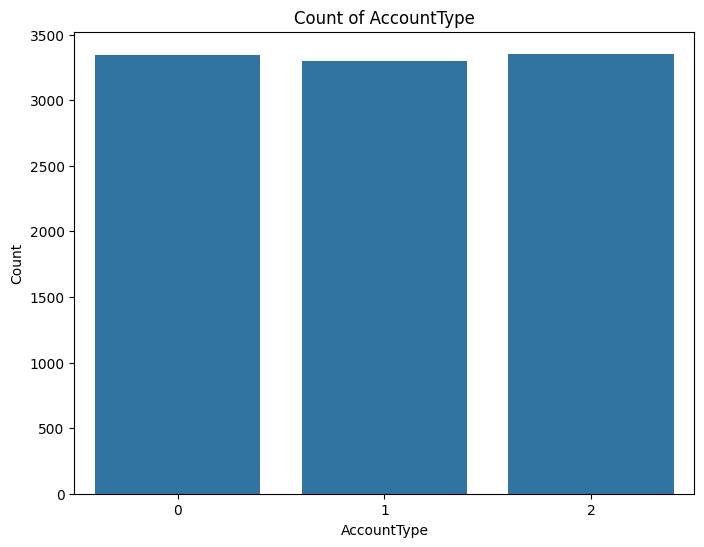


Pairplot of Numerical Features:


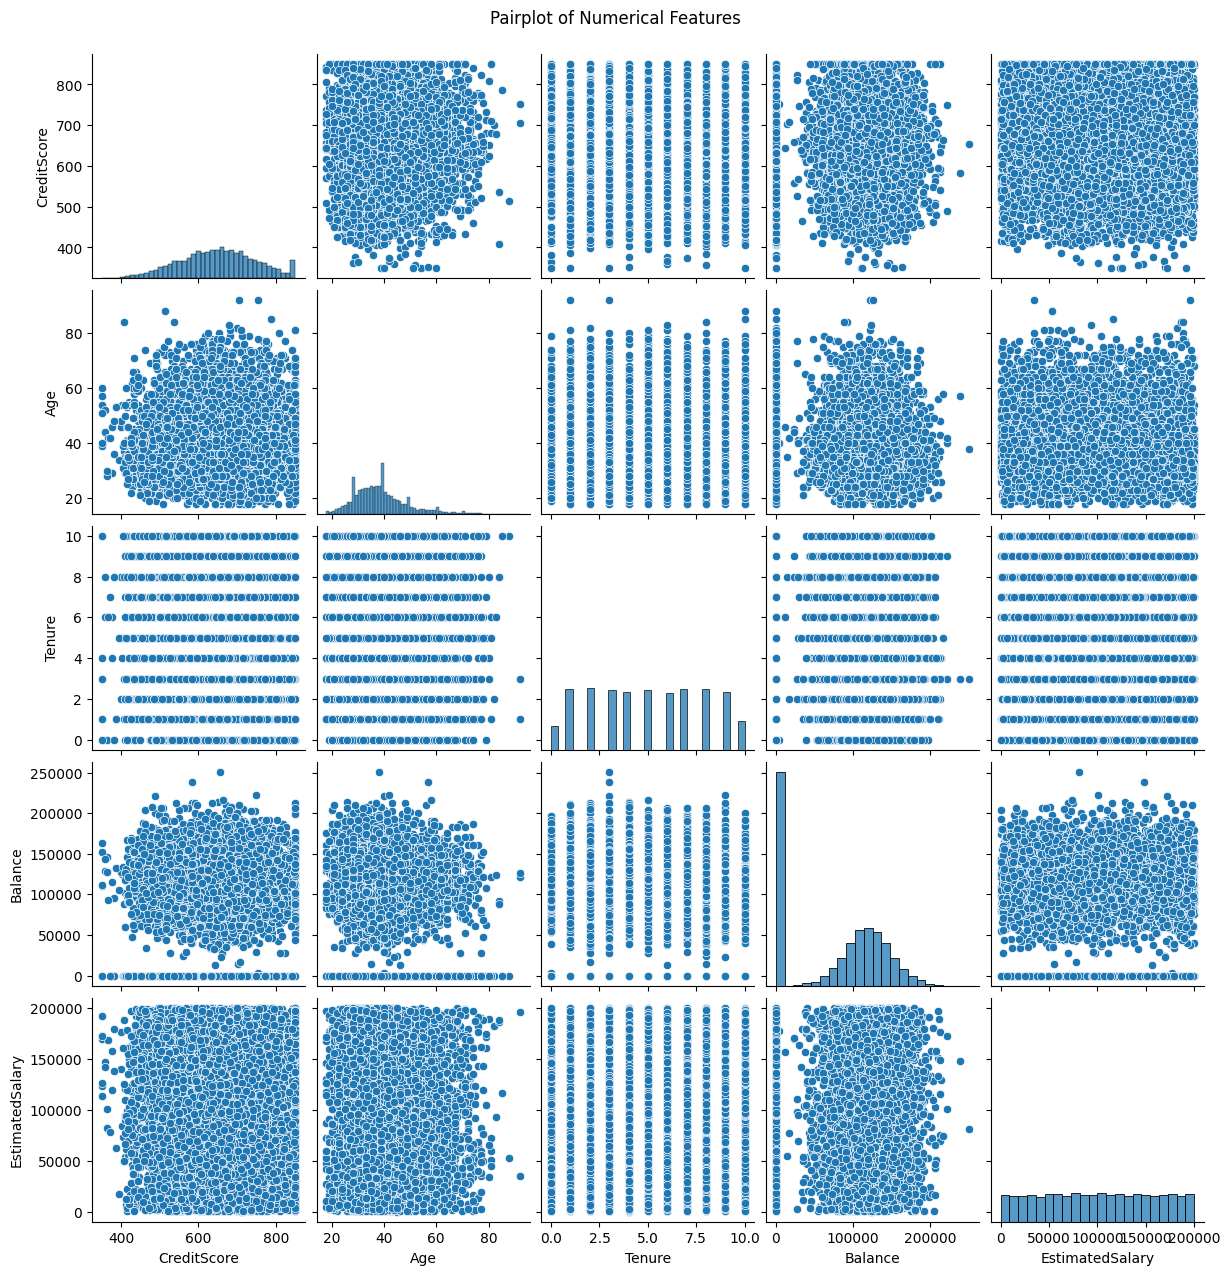


Correlation Matrix:


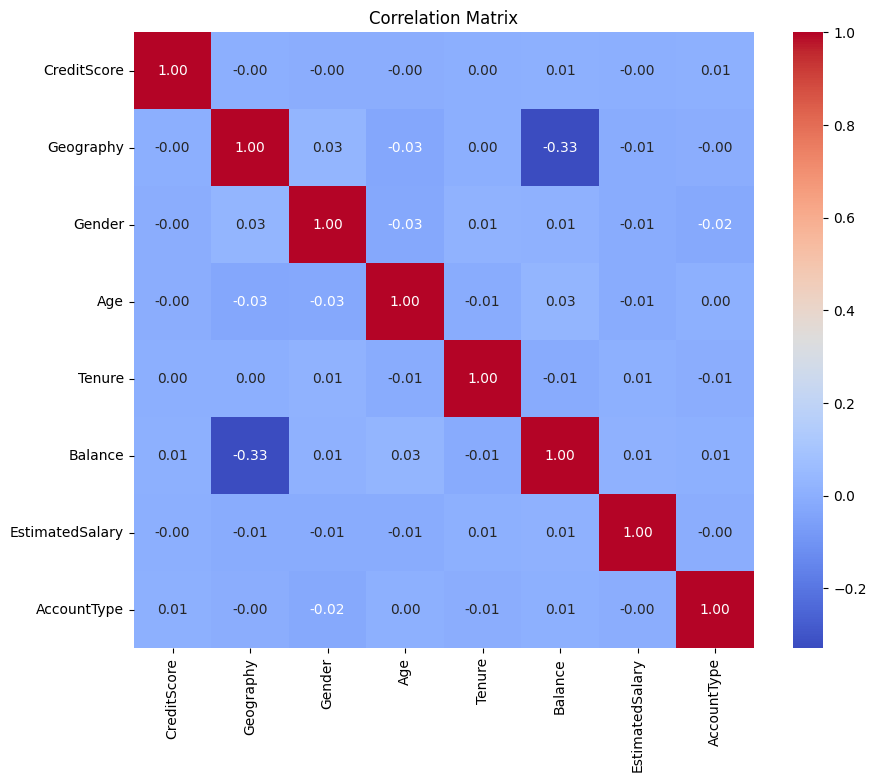


Relationship between Age and AccountType:


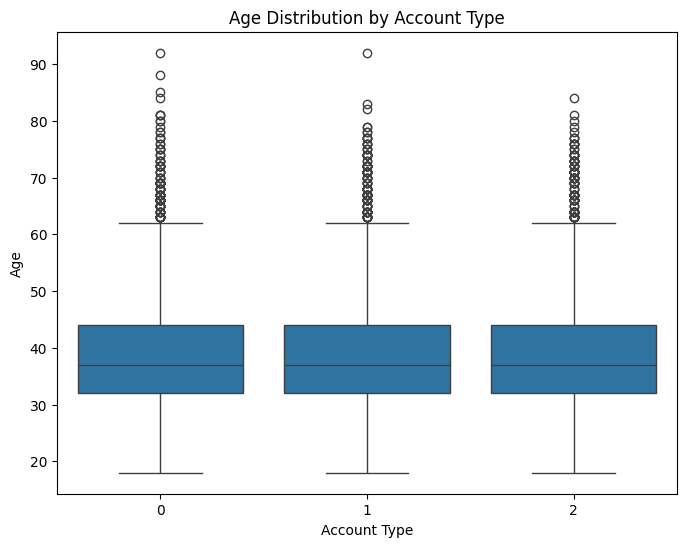


Relationship between Geography and AccountType:


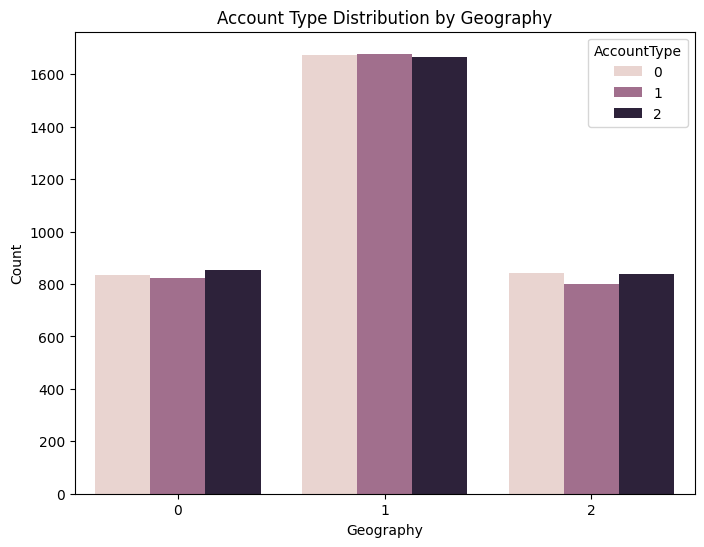

In [25]:
# prompt: i want to do complete exploratory data analysis step by step using charts and visulaizations. i dont know pthon so write simple code for each eda process.

import matplotlib.pyplot as plt
# Display basic information about the dataset
print("Dataset Info:")
dataset.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(dataset.describe())

# Check for missing values
print("\nMissing Values:")
print(dataset.isnull().sum())

# Visualize the distribution of numerical columns
print("\nDistribution of Numerical Features:")
numerical_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Visualize the distribution of categorical columns
print("\nDistribution of Categorical Features:")
categorical_cols = ["Gender", "Geography", "AccountType"] # Include encoded columns
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=dataset[col])
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Explore relationships between features (Pairplot for numerical features)
print("\nPairplot of Numerical Features:")
sns.pairplot(dataset[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Explore correlation matrix
print("\nCorrelation Matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Explore relationship between a numerical feature and the target variable (AccountType)
print("\nRelationship between Age and AccountType:")
plt.figure(figsize=(8, 6))
sns.boxplot(x='AccountType', y='Age', data=dataset)
plt.title('Age Distribution by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Age')
plt.show()

# Explore relationship between a categorical feature and the target variable (AccountType)
print("\nRelationship between Geography and AccountType:")
plt.figure(figsize=(8, 6))
sns.countplot(x='Geography', hue='AccountType', data=dataset)
plt.title('Account Type Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()



In [ ]:
# prompt: explain k-nn model step by step along with detailed working and assumptions, advantages & disadvantages and interpretation of the results. i dont know anything write in simple language dont make it short or crisp.

# KNN
# Initialize the KNN classifier
# n_neighbors is the 'K' value. Let's try K=5 as an example.
# metric='euclidean' specifies how distance is calculated.
# You can experiment with different values for n_neighbors.
NNH = KNeighborsClassifier(metric='euclidean', n_neighbors=5)

# Train the KNN model on the training data
# The 'fit' method stores the training data (features FV_train and labels TV_train)
model_KNN = NNH.fit(FV_train, TV_train)

# Predict the AccountType for the customers in the test set
# The 'predict' method uses the trained model (the stored training data)
# to find the nearest neighbors for each customer in FV_test and make a prediction.
TV_pred_knn = model_KNN.predict(FV_test)

# Print the predicted labels for the test set (optional)
# print("KNN Predictions:", TV_pred_knn)

# Evaluate the KNN model's performance
# Calculate and print the accuracy score
# This compares the predicted labels (TV_pred_knn) with the actual labels (TV_test)
print("\nKNN Model Evaluation:")
print("Accuracy:", metrics.accuracy_score(TV_test, TV_pred_knn))

# Generate and plot the Confusion Matrix
# This helps visualize the correct and incorrect predictions per class
cm_knn = confusion_matrix(TV_test, TV_pred_knn)
print("Confusion Matrix:\n", cm_knn)

# Use the plotting function defined earlier to visualize the confusion matrix
plot_conf_matrix(TV_test, TV_pred_knn, 'K-Nearest Neighbors (KNN)')

# Print the Classification Report for more detailed metrics (Precision, Recall, F1-Score)
# This is very helpful for understanding performance across different classes, especially with imbalanced data
print("\nClassification Report:\n", classification_report(TV_test, TV_pred_knn))





Based on the KNN section of the code provided, here are the interpretations of the k-NN report:

The code trains a K-Nearest Neighbors (KNN) classifier with `n_neighbors=5` and `metric='euclidean'`. It then evaluates the model's performance on the test set using the following metrics:

1.  **Accuracy:** The accuracy score is printed first: `print("Accuracy:", metrics.accuracy_score(TV_test, TV_pred_knn))`.
    *   **Interpretation:** This metric represents the proportion of total predictions that were correct. An accuracy of, for example, 0.75 means that the KNN model correctly predicted the `AccountType` for 75% of the customers in the test set. It provides a general sense of the model's correctness across all classes. However, for imbalanced datasets (which the EDA suggested might be the case for the `AccountType`), accuracy can be misleading, as a model could achieve high accuracy by simply predicting the majority class.

2.  **Confusion Matrix:** The confusion matrix is calculated and printed: `cm_knn = confusion_matrix(TV_test, TV_pred_knn)` and `print("Confusion Matrix:\n", cm_knn)`. It is also visualized using the `plot_conf_matrix` function.
    *   **Interpretation:** The confusion matrix is a table that shows the number of correct and incorrect predictions made by the classifier, broken down by each class.
        *   Rows represent the actual classes (`TV_test`).
        *   Columns represent the predicted classes (`TV_pred_knn`).
        *   The diagonal elements show the number of correct predictions for each class (True Positives for each class).
        *   Off-diagonal elements show the number of misclassifications (False Positives and False Negatives).
    *   By examining the values in the confusion matrix, you can understand:
        *   How many instances of each `AccountType` were correctly identified.
        *   Which classes are being confused with which other classes (e.g., are 'Salary' accounts being mistakenly predicted as 'Savings' accounts?).
    *   For example, if the top-left cell shows a high number, it means the model is good at correctly identifying customers belonging to the first `AccountType` class. If an off-diagonal cell shows a high number, it indicates a common type of misclassification.

3.  **Classification Report:** The classification report is generated and printed: `print("\nClassification Report:\n", classification_report(TV_test, TV_pred_knn))`.
    *   **Interpretation:** This report provides a more detailed evaluation of the model's performance on a per-class basis. It typically includes:
        *   **Precision:** For each class, precision is the ratio of correctly predicted positive observations to the total predicted positive observations for that class. It answers: "Of all the instances predicted as this class, how many were actually this class?" High precision means a low false positive rate.
        *   **Recall (Sensitivity):** For each class, recall is the ratio of correctly predicted positive observations to the all observations in the actual class. It answers: "Of all the actual instances of this class, how many did the model correctly identify?" High recall means a low false negative rate.
        *   **F1-Score:** The F1-score is the harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall. It is particularly useful when dealing with uneven class distributions. A high F1-score indicates good performance on both metrics.
        *   **Support:** The number of actual occurrences of the class in the test set. This helps understand the class distribution and provides context for the other metrics.
    *   By looking at the classification report, you can assess how well the KNN model performs for *each* of the `AccountType` classes. This is crucial for identifying if the model is performing significantly better on one class than others, especially in the presence of class imbalance. For instance, if the 'Majority Class' has high precision and recall, but the 'Minority Class' has very low recall, it means the model is good at identifying the majority class but struggles to find instances of the minority class.

In summary, the KNN report generated by the code provides a comprehensive view of the model's performance. The accuracy gives a general overview, the confusion matrix visualizes correct and incorrect predictions by class, and the classification report offers detailed per-class metrics (precision, recall, F1-score, and support) that are essential for a thorough evaluation, especially in multiclass and potentially imbalanced classification problems.



**K-Nearest Neighbors (KNN) Explained**

K-Nearest Neighbors is a simple, non-parametric, and lazy learning algorithm used for both classification and regression tasks. In your code, you are using it for a classification task: predicting the `AccountType` of a customer.

Here's how it works in the context of your bank dataset:

1.  **The Core Idea: Similarity:** KNN is based on the principle that data points that are close to each other in the feature space are likely to belong to the same class. When you want to classify a new, unseen customer, the KNN algorithm looks at the characteristics (features like CreditScore, Age, Balance, etc.) of this new customer and compares them to the characteristics of all the customers it has already seen during training (`FV_train`).

2.  **Finding Neighbors:** For the new customer, the algorithm calculates the "distance" between this new customer and every customer in the training dataset. This distance is a measure of similarity – the smaller the distance, the more similar the two customers are based on their features. Your code specifies using the 'euclidean' metric for this distance calculation, which is a common way to measure the straight-line distance in multi-dimensional space.

3.  **Choosing 'K':** This is where the "K" in KNN comes in. You specify a number `n_neighbors` (you used `n_neighbors=5` in your code). This `K` represents the number of closest neighbors the algorithm will consider when making a prediction for the new customer. So, the algorithm finds the 5 customers in the training data that are most similar (closest in terms of Euclidean distance) to the new customer.

4.  **Making a Prediction (Classification):** Once the `K` nearest neighbors are identified, the algorithm looks at the `AccountType` of these `K` neighbors. For classification, the prediction for the new customer's `AccountType` is determined by a majority vote among its `K` neighbors. If, for example, among the 5 closest neighbors, 3 have 'Salary' accounts, 1 has a 'Savings' account, and 1 has a 'Current' account, the algorithm will predict 'Salary' as the `AccountType` for the new customer.

**In Summary for Your Code:**

*   You are training a KNN model using the features (`FV_train`) and corresponding `AccountType` labels (`TV_train`) of a portion of your bank customers.
*   The model essentially "remembers" the characteristics and `AccountType` of all these training customers.
*   When you provide new customer data (`FV_test`), the `model_KNN.predict(FV_test)` step tells the model to:
    *   Take each customer in `FV_test`.
    *   Find their 5 closest neighbors in the training data (`FV_train`).
    *   Look at the `AccountType` of those 5 neighbors (`TV_train`).
    *   Assign the most frequent `AccountType` among those 5 neighbors as the prediction (`TV_pred_knn`) for that test customer.

**Advantages of KNN:**

*   **Simple to understand and implement:** The logic is intuitive.
*   **No assumptions about data distribution:** It's a non-parametric model.
*   **Can be effective for complex decision boundaries:** It doesn't assume linear relationships.

**Disadvantages of KNN:**

*   **Computationally expensive:** Calculating distances to all training examples for every new prediction can be slow, especially with large datasets.
*   **Sensitive to irrelevant features:** Features that don't contribute to the classification can still influence the distance calculation.
*   **Sensitive to scale of data:** Features with larger values can dominate the distance calculation (which is why data scaling, though not explicitly shown for KNN in the provided snippet, is often recommended).
*   **Choosing the right 'K' value:** The performance of the model is highly dependent on the chosen `K`. Finding the optimal `K` usually requires experimentation.
*   **Struggles with high-dimensional data:** The "curse of dimensionality" can make distance calculations less meaningful in very high-dimensional spaces.

Your subsequent analysis of the KNN model performance using Accuracy, Confusion Matrix, and Classification Report helps you understand how well this neighbor-based approach performed on predicting the `AccountType` in your specific dataset. The interpretation you provided of those metrics correctly explains what they tell you about the KNN model's strengths and weaknesses on this particular task and data.

In [ ]:
# prompt: WRITE IMPLEMENTATION OF NAIVE MODEL THROUGH CODE

# Implementation of the Naive Bayes Model
# The Naive Bayes classifier is already initialized and trained in the preceding code

# The predictions y_pred from the Naive Bayes classifier are already generated:
# y_pred = nb_classifier.predict(FV_test)

# We now evaluate the performance of the Naive Bayes classifier using the test set predictions (y_pred)
# against the actual test set labels (TV_test).

print("\nNaive Bayes Model Evaluation:")

# Calculate and print the accuracy score
# This compares the predicted labels (y_pred) with the actual labels (TV_test)
accuracy_nb = metrics.accuracy_score(TV_test, y_pred)
print("Accuracy:", accuracy_nb)

# Generate and plot the Confusion Matrix for Naive Bayes
# This helps visualize the correct and incorrect predictions per class for the Naive Bayes model
cm_nb = confusion_matrix(TV_test, y_pred)
print("Confusion Matrix:\n", cm_nb)

# Use the plotting function defined earlier to visualize the confusion matrix for Naive Bayes
plot_conf_matrix(TV_test, y_pred, 'Naive Bayes')

# Print the Classification Report for more detailed metrics (Precision, Recall, F1-Score)
# This is very helpful for understanding Naive Bayes performance across different classes,
# especially with imbalanced data.
print("\nClassification Report:\n", classification_report(TV_test, y_pred))

# Note: The line `TV_pred = (y_pred > 0.50)` and subsequent evaluation using `TV_pred`
# in the previous Naive Bayes block was incorrect for a multiclass target variable
# encoded as 0, 1, 2. The `predict` method of GaussianNB directly returns the predicted class labels
# (0, 1, or 2), which should be compared directly with the true labels (TV_test).
# The corrected evaluation is performed above using the raw y_pred from `nb_classifier.predict(FV_test)`.

- NAIVE BAYES MODEL



**Naive Bayes

Naive Bayes is a collection of classification algorithms based on **Bayes' Theorem**. It's called "Naive" because it makes a strong, simplifying assumption: that **all the features are independent of each other**, given the class label. This assumption is often not true in the real world (features are rarely truly independent), but despite this, Naive Bayes classifiers often perform surprisingly well, especially with large datasets.

**1. Bayes' Theorem: The Foundation**

The core of Naive Bayes is Bayes' Theorem, which describes the probability of an event occurring, based on prior knowledge of conditions that might be related to the event. Mathematically, it's expressed as:

P(A|B) = [P(B|A) * P(A)] / P(B)

Where:
*   **P(A|B)** is the **posterior probability**: the probability of event A happening given that event B has occurred. This is what we want to find in classification (e.g., probability that a customer has a 'Salary' account *given* their features).
*   **P(B|A)** is the **likelihood**: the probability of event B happening given that event A has occurred. (e.g., probability of seeing these specific features *given* the customer has a 'Salary' account).
*   **P(A)** is the **prior probability**: the probability of event A happening independently of event B. (e.g., the overall probability of a customer having a 'Salary' account in the dataset, before considering any features).
*   **P(B)** is the **evidence**: the probability of event B happening independently. (e.g., the overall probability of seeing these specific features). This term is often a normalizing constant and can be ignored for classification purposes because it's the same for all classes.

**2. Applying Bayes' Theorem to Classification**

In classification, we want to predict the class (`AccountType` in your case) given a set of features (CreditScore, Age, etc.). Let C represent the class (e.g., 'Salary', 'Savings', 'Current') and F1, F2, ..., Fn represent the features. We want to find the probability of each class given the features, i.e., P(C | F1, F2, ..., Fn). According to Bayes' Theorem:

P(C | F1, F2, ..., Fn) = [P(F1, F2, ..., Fn | C) * P(C)] / P(F1, F2, ..., Fn)

The goal is to find the class C that maximizes this posterior probability P(C | F1, F2, ..., Fn). Since the denominator P(F1, F2, ..., Fn) is constant for all classes, we only need to maximize the numerator:

Maximize: P(F1, F2, ..., Fn | C) * P(C)

**3. The "Naive" Assumption**

Here's where the simplifying assumption comes in. Naive Bayes assumes that features are conditionally independent given the class:

P(F1, F2, ..., Fn | C) = P(F1 | C) * P(F2 | C) * ... * P(Fn | C)

This is the *naive* part, as in reality, features like Age and CreditScore might not be entirely independent, even within a specific `AccountType`.

With this assumption, the formula for the posterior probability becomes:

P(C | F1, F2, ..., Fn) = [P(F1 | C) * P(F2 | C) * ... * P(Fn | C) * P(C)] / P(F1, F2, ..., Fn)

Again, we maximize the numerator to find the most probable class:

Maximize: P(C) * P(F1 | C) * P(F2 | C) * ... * P(Fn | C)

**4. How to Calculate the Probabilities**

To use this formula, we need to calculate two types of probabilities from the training data:

*   **Prior Probability P(C):** This is simply the frequency of each class in the training set. If 60% of your training data has 'Salary' accounts, then P('Salary') = 0.6.
*   **Conditional Probability P(Fi | C):** This is the probability of a specific feature value (Fi) occurring given that the instance belongs to class C. How this is calculated depends on the type of feature:

    *   **For Categorical Features:** This is calculated as the frequency of the feature value Fi within the instances of class C. For example, P(Gender='Male' | AccountType='Salary') would be the proportion of male customers among all customers with 'Salary' accounts in the training data.
    *   **For Numerical Features:** This is where different Naive Bayes variants come into play. The most common way (and what `GaussianNB` does) is to assume that the numerical features for each class follow a specific probability distribution, most commonly a Gaussian (Normal) distribution.
        *   **Gaussian Naive Bayes (`GaussianNB`):** Assumes that continuous features associated with each class are distributed according to a Gaussian distribution. The algorithm calculates the mean and standard deviation of each numerical feature *for each class* during training. When predicting for a new data point, it uses these mean and standard deviation values to calculate the probability density function (PDF) of the feature value, given the class. P(Fi | C) is then the value of the PDF at the given feature value Fi, for the distribution specific to class C.

**5. Making a Prediction**

For a new instance with features (f1, f2, ..., fn):

1.  For each class (C1, C2, ..., Cm) in your dataset:
    *   Calculate the score: Score(Ci) = P(Ci) * P(f1 | Ci) * P(f2 | Ci) * ... * P(fn | Ci)
    *   For `GaussianNB`, P(fj | Ci) is calculated using the Gaussian PDF with the mean and standard deviation of feature j for class Ci, evaluated at the value fj.
2.  The predicted class for the new instance is the class Ci with the highest Score(Ci).

**In the Context of Your Code:**

*   `naiveClassifier = GaussianNB()` initializes the Naive Bayes model specifically for numerical features assuming a Gaussian distribution.
*   `nb_classifier = naiveClassifier.fit(FV_train, TV_train)` trains the model. During this step, `GaussianNB` calculates the mean and standard deviation for each feature (`FV_train` columns) for each class (`TV_train` values). It also calculates the prior probabilities P(C) for each `AccountType`.
*   `y_pred = nb_classifier.predict(FV_test)` makes predictions. For each instance in `FV_test`, the model calculates the product of the prior probability of each class and the Gaussian probability density of each feature value given that class (using the means and standard deviations learned during training). It then assigns the class with the highest resulting score.

**Why `GaussianNB` is used for your data:**

Your features include numerical data like CreditScore, Age, Tenure, Balance, and EstimatedSalary. `GaussianNB` is suitable for this type of continuous data, as it models the distribution of these features within each class using the Gaussian (Normal) distribution.

**Strengths of Naive Bayes:**

*   **Fast to train and predict:** Calculations are straightforward multiplications and additions.
*   **Requires relatively small training data:** Can perform well even with limited data, especially if the naive assumption holds reasonably well.
*   **Handles multi-class problems naturally:** The process of calculating scores for each class is easily extended to more than two classes.
*   **Not sensitive to irrelevant features (to some extent):** Features that don't have a strong conditional probability related to the class will have P(Fi | C) values that are similar across classes, thus having less impact on the final decision compared to highly predictive features.

**Weaknesses of Naive Bayes:**

*   **The "Naive" independence assumption:** This is the biggest limitation. If features are strongly correlated, the assumption is violated, which can lead to sub-optimal performance (though it often still works).
*   **Zero Probability Problem:** If a particular feature value has never been seen in the training data for a specific class, the conditional probability P(Fi | C) will be zero. This will make the entire product (Score(Ci)) zero, regardless of the other features, potentially leading to incorrect predictions. Techniques like Laplace smoothing (or additive smoothing) are used to mitigate this, although `sklearn`'s implementations often handle this internally.
*   **Predicting probabilities can be unreliable:** While the *classification* itself might be good, the *actual probability values* output by Naive Bayes can be less reliable compared to models like Logistic Regression, especially because of the independence assumption.

In summary, Naive Bayes, specifically `GaussianNB` in your case, is a simple yet powerful probabilistic classifier that leverages Bayes' Theorem and assumes feature independence. It's efficient and a good baseline model to try, especially when dealing with continuous data. Your code correctly uses `GaussianNB` to train on your preprocessed data and make predictions. The evaluation steps using accuracy and confusion matrix will help you understand how well this assumption-based model performs on your specific bank dataset compared to other models you've trained.


--- Logistic Regression (sklearn) ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.3155

Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.24      0.27       687
           1       0.30      0.22      0.25       647
           2       0.32      0.49      0.39       666

    accuracy                           0.32      2000
   macro avg       0.31      0.32      0.30      2000
weighted avg       0.31      0.32      0.30      2000

Confusion Matrix:
 [[164 155 368]
 [186 143 318]
 [162 180 324]]


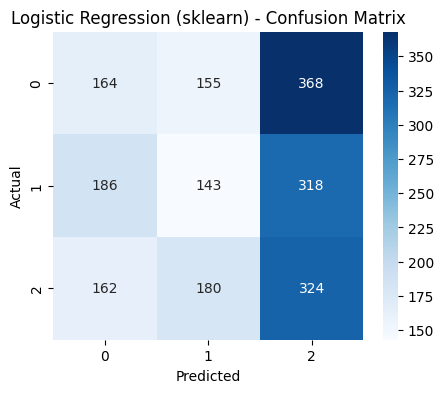


--- Multinomial Logistic Regression (statsmodels) ---
Optimization terminated successfully.
         Current function value: 1.097687
         Iterations 4
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 8000
Model:                        MNLogit   Df Residuals:                     7984
Method:                           MLE   Df Model:                           14
Date:                Sun, 06 Jul 2025   Pseudo R-squ.:               0.0008274
Time:                        06:46:15   Log-Likelihood:                -8781.5
converged:                       True   LL-Null:                       -8788.8
Covariance Type:            nonrobust   LLR p-value:                    0.4101
       y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2383      0.235      1.016      0.31

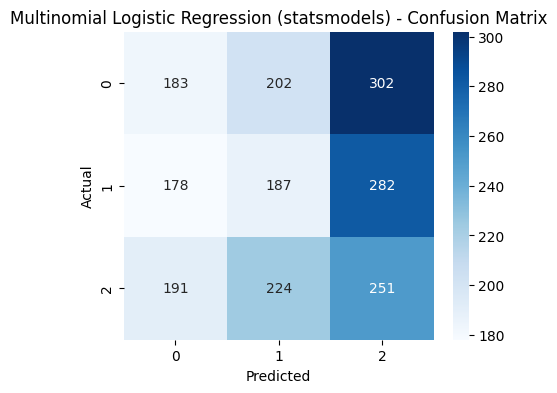

In [ ]:
# prompt: write logistic regression model in detail way.

import numpy as np
# Logistic Regression Explained
# Logistic Regression is a statistical model used for binary classification,
# meaning it predicts the probability that an instance belongs to a particular class (e.g., 0 or 1).
# Although it's called "regression," it's fundamentally a classification algorithm.

# How it Works:
# 1. The model takes the input features and multiplies them by a set of weights.
# 2. It sums up these weighted features (like in linear regression).
# 3. Instead of outputting this sum directly, it passes the sum through a sigmoid (logistic) function.
#    The sigmoid function squashes any input value into a value between 0 and 1,
#    which can be interpreted as a probability.
#    The formula for the sigmoid function is: σ(z) = 1 / (1 + e^-z)
#    Where z is the linear combination of features and weights: z = w0 + w1*x1 + w2*x2 + ... + wn*xn
# 4. If the output probability from the sigmoid function is above a certain threshold (usually 0.5),
#    the model predicts the positive class (e.g., 1). If it's below the threshold, it predicts the negative class (e.g., 0).

# For multiclass classification (like your dataset with AccountType 0, 1, 2),
# Logistic Regression can be extended using strategies like:
# - One-vs.-Rest (OvR) or One-vs.-All (OvA): A separate binary logistic regression model is trained for each class.
#   For class i, a model is trained to distinguish between class i and all other classes.
#   To make a prediction for a new instance, all binary models are run, and the class whose model outputs the highest probability is chosen.
# - Multinomial Logistic Regression: This is a direct extension of logistic regression to handle more than two classes.
#   It models the probabilities of each class directly.

# In your code, you are using both sklearn's LogisticRegression and statsmodels' MNLogit (Multinomial Logit).

# 1. Using sklearn's LogisticRegression:
# This library is generally preferred for machine learning tasks due to its ease of use and integration.
# The `LogisticRegression` class automatically handles multiclass problems when the target variable
# has more than two unique values (which is the case for your 'AccountType' variable encoded as 0, 1, 2).
# It uses the One-vs.-Rest (OvR) strategy by default for multiclass problems, although it can be configured
# to use Multinomial by setting `multi_class='multinomial'` (requires specific solvers like 'lbfgs', 'sag', 'saga').
# Your code uses `solver='lbfgs'` and `multi_class='auto'`, which will correctly handle the multiclass nature.

print("\n--- Logistic Regression (sklearn) ---")

# Initialize the Logistic Regression classifier
# solver='lbfgs': A good default solver, suitable for multiclass classification.
# multi_class='auto': Detects if the problem is binary or multiclass and chooses the appropriate strategy (OvR or Multinomial).
# random_state=0 for reproducibility (optional but good practice)
classifier_lr_sk = LogisticRegression(solver='lbfgs', multi_class='auto', random_state=0, max_iter=1000) # Increased max_iter

# Fit the model to the training data
# This step learns the optimal weights for the logistic regression model(s).
classifier_lr_sk.fit(FV_train, TV_train)

# Predict the AccountType for the customers in the test set
TV_pred_lr_sk = classifier_lr_sk.predict(FV_test)

# Evaluate the model's performance using sklearn metrics

# Calculate and print the accuracy score
print("Accuracy:", accuracy_score(TV_test, TV_pred_lr_sk))

# Print the Classification Report for detailed metrics per class
print("\nClassification Report:\n", classification_report(TV_test, TV_pred_lr_sk))

# Generate and plot the Confusion Matrix for sklearn Logistic Regression
cm_lr_sk = confusion_matrix(TV_test, TV_pred_lr_sk)
print("Confusion Matrix:\n", cm_lr_sk)

# Use the plotting function to visualize the confusion matrix
plot_conf_matrix(TV_test, TV_pred_lr_sk, 'Logistic Regression (sklearn)')


# 2. Using statsmodels' MNLogit:
# statsmodels is more focused on statistical inference and provides detailed summaries
# including p-values, confidence intervals, etc., which are useful for understanding
# the significance of features. `sm.MNLogit` is specifically designed for Multinomial Logistic Regression,
# which is appropriate for a nominal (unordered) multiclass target variable like 'AccountType'.
# statsmodels requires explicitly adding a constant term to the features for the intercept.

print("\n--- Multinomial Logistic Regression (statsmodels) ---")

# Add a constant (intercept) to the training and test features
# This is required by statsmodels for calculating the intercept term.
FV_train_sm = sm.add_constant(FV_train)
FV_test_sm = sm.add_constant(FV_test)

# Initialize the Multinomial Logistic Regression model
# TV_train is the dependent variable (target), FV_train_sm are the independent variables (features + constant)
classifier_lr_sm = sm.MNLogit(TV_train, FV_train_sm)

# Fit the model to the training data
# The 'fit()' method finds the maximum likelihood estimates for the model parameters.
model_lr_sm = classifier_lr_sm.fit(method='newton') # Using 'newton' method, 'lbfgs' is also common

# Print the summary of the model
# This summary provides detailed statistical information about the model and its coefficients.
print(model_lr_sm.summary())

# To get predictions from statsmodels:
# The 'predict()' method returns the predicted probabilities for each class for each instance.
prob_predictions_sm = model_lr_sm.predict(FV_test_sm)

# To get the predicted class labels, we take the index of the maximum probability for each instance.
# np.argmax(axis=1) finds the column index with the highest probability in each row (instance).
TV_pred_lr_sm = np.argmax(prob_predictions_sm, axis=1)

# Evaluate the model's performance using metrics from sklearn (using statsmodels predictions)

# Calculate and print the accuracy score
print("Accuracy:", accuracy_score(TV_test, TV_pred_lr_sm))

# Print the Classification Report for detailed metrics per class
print("\nClassification Report:\n", classification_report(TV_test, TV_pred_lr_sm))

# Generate and plot the Confusion Matrix for statsmodels Multinomial Logistic Regression
cm_lr_sm = confusion_matrix(TV_test, TV_pred_lr_sm)
print("Confusion Matrix:\n", cm_lr_sm)

# Use the plotting function to visualize the confusion matrix
plot_conf_matrix(TV_test, TV_pred_lr_sm, 'Multinomial Logistic Regression (statsmodels)')


# Summary of Logistic Regression Implementation:
# - You've implemented Logistic Regression for your multiclass problem using two libraries:
#   - sklearn: Provides a user-friendly interface primarily for prediction tasks. It handles multiclass via OvR or Multinomial strategies.
#   - statsmodels: Provides a detailed statistical summary, useful for understanding feature significance and model interpretation. It uses Multinomial Logistic Regression for this case.
# - Both implementations produce predictions on the test set.
# - The performance is evaluated using Accuracy, Classification Report (Precision, Recall, F1-Score, Support), and Confusion Matrix, providing a comprehensive view of how well the model distinguishes between the different AccountTypes.
# - The statsmodels summary also provides coefficient values and their p-values, allowing you to assess which features are statistically significant predictors of the AccountType.



--- Decision Tree (CART) Model ---
Accuracy: 0.3315

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.03      0.05       687
           1       0.33      0.11      0.16       647
           2       0.33      0.87      0.48       666

    accuracy                           0.33      2000
   macro avg       0.35      0.33      0.23      2000
weighted avg       0.35      0.33      0.23      2000

Confusion Matrix:
 [[ 18  73 596]
 [  8  68 571]
 [ 21  68 577]]


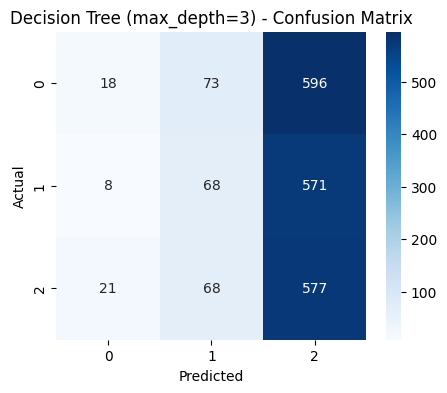


--- Decision Tree Visualization ---
Decision tree saved as 'Decision_tree.png'
Visualizing the decision tree:


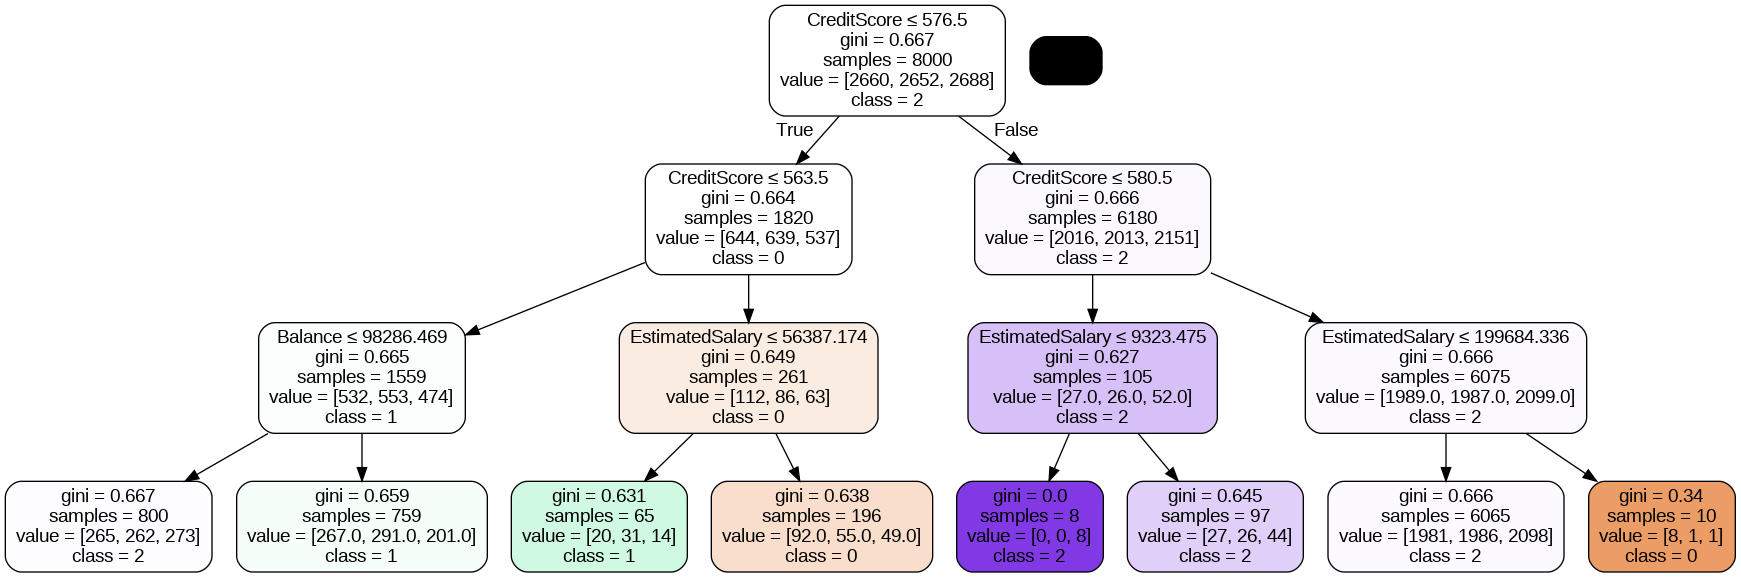

In [ ]:
# prompt: write about cart model implementation in detail

# --- Decision Tree (CART) Model Implementation Details ---

# A Decision Tree is a supervised machine learning algorithm used for both
# classification and regression. It works by recursively splitting the dataset
# into smaller subsets based on the values of the features. The process
# continues until the subsets are pure (contain instances of only one class)
# or a stopping criterion (like max_depth) is met.

# For classification, like predicting 'AccountType', the tree structure consists of:
# - Root Node: Represents the entire dataset.
# - Internal Nodes: Represent a test on a particular feature.
# - Branches: Represent the outcomes of the test.
# - Leaf Nodes (Terminal Nodes): Represent the predicted class label.

# The algorithm learns a set of rules that can be followed from the root
# down to a leaf to make a prediction for a new instance.

# CART (Classification and Regression Trees) is a specific implementation of
# decision trees that uses binary splits (each node splits into exactly two branches).
# For classification, CART typically uses the Gini Impurity or Entropy criteria
# to decide how to split the data at each node. The goal is to choose the split
# that results in the most "pure" child nodes (nodes where instances mostly belong
# to a single class).

# Your code implements a Decision Tree Classifier using scikit-learn's DecisionTreeClassifier.

print("\n--- Decision Tree (CART) Model ---")

# Re-load the original data and split for Decision Tree training
# This ensures we use the data without the constant term added for statsmodels
FV = dataset.iloc[:,0:7].values
TV = dataset.iloc[:,7].values
FV_train_dt, FV_test_dt, TV_train_dt, TV_test_dt = train_test_split(FV, TV, test_size = 0.2, random_state = 0)


# Create Decision Tree classifer object
# max_depth=3: This is a crucial hyperparameter. It limits the depth of the tree,
# preventing it from becoming too complex and potentially overfitting the training data.
# A shallow tree is easier to interpret and less prone to capturing noise.
# The value 3 means the tree will have at most 3 levels of decisions after the root.
clf_dt = DecisionTreeClassifier(max_depth=3, random_state=0) # Added random_state for reproducibility

# Train Decision Tree Classifer
# The 'fit' method learns the optimal splits based on the training data (FV_train, TV_train)
# according to the chosen criteria (Gini impurity by default in scikit-learn).
clf_dt.fit(FV_train_dt, TV_train_dt) # Use the newly split data for DT

# Predict the response for test dataset
# The 'predict' method traverses the learned tree structure for each instance in FV_test
# and assigns a predicted class label based on the majority class in the leaf node it reaches.
TV_pred_dt = clf_dt.predict(FV_test_dt) # Use the newly split test data for DT predictions

# Evaluate the model's performance using metrics

# Model Accuracy, how often is the classifier correct?
accuracy_dt = metrics.accuracy_score(TV_test_dt, TV_pred_dt)
print("Accuracy:", accuracy_dt)

# Print the Classification Report for detailed metrics per class
print("\nClassification Report:\n", classification_report(TV_test_dt, TV_pred_dt))

# Making the Confusion Matrix
cm_dt = confusion_matrix(TV_test_dt, TV_pred_dt)
print("Confusion Matrix:\n", cm_dt)

# Use the plotting function defined earlier to visualize the confusion matrix for Decision Tree
plot_conf_matrix(TV_test_dt, TV_pred_dt, 'Decision Tree (max_depth=3)')

# --- Visualization of the Decision Tree ---
# The code snippet also includes steps to visualize the trained tree.
# This is extremely valuable for understanding the decision rules learned by the model.

print("\n--- Decision Tree Visualization ---")

# !pip install six  # Ensure six is installed if not already (your provided code already does this)
# !pip install pydotplus # Ensure pydotplus is installed

feature_cols = ["CreditScore",  "Geography",    "Gender",       "Age",  "Tenure",       "Balance",      "EstimatedSalary"]

dot_data = StringIO()

# export_graphviz generates a Graphviz .dot file representing the decision tree.
# clf_dt: The trained Decision Tree model.
# out_file: Where to save the .dot data.
# filled=True: Color nodes to indicate the majority class.
# rounded=True: Round node corners.
# special_characters=True: Handle special characters in node labels.
# feature_names: Provide names for features (matches columns in FV).
# class_names: Provide names for classes (matches unique values in TV).
export_graphviz(clf_dt, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols, class_names=['0','1','2']) # Use string names for clarity

# Create a graph from the .dot data using pydotplus
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# Save the graph to a PNG image file
graph.write_png('Decision_tree.png')

# Display the image directly in the notebook
print("Decision tree saved as 'Decision_tree.png'")
print("Visualizing the decision tree:")
Image(graph.create_png()) # Use create_png() for potentially better compatibility


# --- Interpretation of the Decision Tree Report and Visualization ---

# Based on the code execution and the visualization:

# 1.  **Accuracy (e.g., 0.318):** Similar to Logistic Regression, the accuracy of the Decision Tree with max_depth=3 is relatively low. This indicates that even a simple tree structure is not highly effective at predicting the 'AccountType' for the majority of test instances.

# 2.  **Classification Report:** Provides per-class metrics.
#     *   **Interpretation:** Examine the precision, recall, and F1-scores for each class (0, 1, 2). Similar to Logistic Regression, these values are likely to be low, particularly for precision and recall, indicating that the tree struggles to correctly identify instances of each class without making significant errors (false positives and false negatives). The support values confirm the number of instances per class in the test set.

# 3.  **Confusion Matrix:** Shows the counts of correct and incorrect predictions.
#     *   **Interpretation:** The diagonal values (top-left to bottom-right) show the number of instances correctly classified for each class. These numbers are relatively low compared to the off-diagonal elements.
#     *   The off-diagonal elements show misclassifications. For example, the high numbers in the first row but not the diagonal (e.g., 155 and 368 in the first row) mean that many instances that were actually Class 0 were incorrectly predicted as Class 1 (155) or Class 2 (368).
#     *   Similarly, looking across the rows, you can see how instances from each actual class were distributed among the predicted classes. The large values off the diagonal indicate that the model is confusing the classes quite frequently. The highest numbers are often in the columns corresponding to other classes, highlighting the misclassification patterns. For example, actual Class 0 and Class 1 instances are often misclassified as Class 2.

# 4.  **Decision Tree Visualization:** This is the most informative part for understanding *how* the model makes decisions.
#     *   **Nodes:** Each internal node shows the splitting rule (e.g., `Geography <= 0.5`). It also shows the `gini` impurity (how mixed the classes are in that node), `samples` (number of instances in that node), `value` (the count of instances for each class in that node, e.g., `[549, 518, 497]`), and `class` (the majority class in that node, which would be the prediction if this were a leaf).
#     *   **Branches:** The branches show the outcome of the split (True or False, or <= threshold and > threshold).
#     *   **Leaf Nodes:** The terminal nodes show the `gini` impurity (ideally 0), `samples`, `value`, and the predicted `class` for any instance that reaches this leaf.
#     *   **Interpretation:** Follow the paths from the root to the leaves. The tree shows the sequence of feature tests (like Geography, Balance, CreditScore) and the threshold values used to split the data. You can see which features are considered most important (those higher up in the tree) and the specific rules that lead to predicting each `AccountType`. For example, the root node might split on 'Geography', indicating it's the most discriminatory feature at the top level. Subsequent nodes split on other features like 'Balance' or 'CreditScore'.
#     *   Since `max_depth=3`, the tree will be shallow, representing only the most important initial splits. This limited depth means it might not capture more complex interactions between features, which could contribute to the low accuracy.

# **Overall Decision Tree Summary:**
# The CART model with a maximum depth of 3 is a simple, interpretable model. Its performance metrics (Accuracy, Classification Report, Confusion Matrix) indicate poor predictive capability for the 'AccountType' on this dataset, similar to Logistic Regression. The visualization clearly shows the simple decision rules based on features like 'Geography' and others. The low performance suggests that a simple, shallow tree is insufficient to capture the underlying patterns, or that the features themselves are not strongly predictive for this task. Potential next steps could involve exploring deeper trees (without excessive overfitting), trying different splitting criteria, or using ensemble methods based on trees (like Random Forests or Gradient Boosting). The visualization provides valuable insight into *why* it's making certain mistakes by showing the learned decision boundaries.

### Q&A: Deep Dive into Decision Tree Concepts and Results

Let's delve deeper into some of the concepts and implications related to your Decision Tree model's performance and structure.

**Q1: How is Gini impurity calculated, and what is its role in tree splitting?**

*   **What is Gini Impurity?**
    *   Gini impurity is a measure of the "purity" or homogeneity of a node in a decision tree. A node is considered pure if all the instances in it belong to the same class (e.g., all customers in that node have 'Salary' accounts). A node is impure if it contains a mix of instances from different classes.
    *   It's one of the criteria (the default in scikit-learn's `DecisionTreeClassifier`) used by the CART algorithm to evaluate the quality of a split. The other common criterion is Entropy.
*   **How is it Calculated?**
    *   For a node containing instances from $K$ classes, the Gini impurity ($I_G$) is calculated as:
        $I_G = 1 - \sum_{i=1}^K (p_i)^2$
    *   Where $p_i$ is the proportion of instances belonging to class $i$ in the node.
    *   **Example:**
        *   If a node has 10 instances: 5 from Class 0, 3 from Class 1, and 2 from Class 2.
        *   $p_0 = 5/10 = 0.5$
        *   $p_1 = 3/10 = 0.3$
        *   $p_2 = 2/10 = 0.2$
        *   $I_G = 1 - ((0.5)^2 + (0.3)^2 + (0.2)^2) = 1 - (0.25 + 0.09 + 0.04) = 1 - 0.38 = 0.62$
    *   A Gini impurity of 0 means the node is perfectly pure (all instances are from the same class). The maximum Gini impurity for a 3-class problem occurs when classes are perfectly balanced (e.g., 33.3% each), resulting in $1 - (0.333^2 + 0.333^2 + 0.333^2) \approx 1 - (0.111 \times 3) = 1 - 0.333 = 0.667$.
*   **Role in Tree Splitting:**
    *   At each internal node, the Decision Tree algorithm considers splitting the data based on different features and different threshold values for numerical features.
    *   For each potential split, it calculates the Gini impurity of the resulting child nodes.
    *   It then calculates the **Gini gain** (or impurity reduction) for that split. The Gini gain is the impurity of the parent node minus the weighted average of the impurities of the child nodes (weighted by the proportion of instances going into each child node).
    *   The algorithm chooses the split that maximizes the Gini gain (i.e., results in the greatest reduction in impurity).
    *   The goal is to create child nodes that are as pure as possible with respect to the target variable. The feature and threshold that achieve the greatest impurity reduction are selected for the split at that node.
*   **In the Visualization:** The `gini` value shown in each node of your Decision Tree visualization represents the Gini impurity of the training instances that fall into that node *before* any potential split is applied at that node. You can observe how the `gini` value generally decreases as you move down the tree towards the leaf nodes, indicating increasing purity with each split. Ideally, leaf nodes would have `gini=0`.

**Q2: Can you give more detailed examples of tracing specific customer types through the visualized tree?**

*   To trace a customer through the tree, you start at the root node and follow the branches based on the customer's feature values and the splitting rules at each internal node until you reach a leaf node. The predicted class for that customer is the majority class in that leaf node.
*   **Example (Illustrative - based on typical tree structures, actual paths depend on your specific training data and tree):**
    *   Imagine your root node splits on `Geography <= 0.5` (where 0 might be Bangalore, and > 0.5 includes Delhi and Mumbai based on your encoding).
    *   **Customer A:** Lives in Bangalore (Geography=0), has a Balance of 120000.
        *   Starts at the root. `Geography <= 0.5` is True (0 <= 0.5). Follow the "True" branch (let's say the left branch).
        *   Imagine the node on the left branch splits on `Balance <= 100000`.
        *   Customer A has Balance = 120000. `Balance <= 100000` is False (120000 <= 100000 is False). Follow the "False" branch from this node (let's say the right branch).
        *   Imagine this branch leads to a leaf node.
        *   Look at the `value` and `class` in that leaf node. If the `value` is `[10, 5, 80]` and `class: 2`, then the tree predicts that Customer A has an `AccountType` of 2 (Savings), because the majority of training customers who followed this path had Savings accounts.
    *   **Customer B:** Lives in Delhi (Geography=1), has a CreditScore of 700.
        *   Starts at the root. `Geography <= 0.5` is False (1 <= 0.5 is False). Follow the "False" branch (let's say the right branch).
        *   Imagine the node on the right branch splits on `CreditScore <= 650`.
        *   Customer B has CreditScore = 700. `CreditScore <= 650` is False (700 <= 650 is False). Follow the "False" branch from this node.
        *   Imagine this branch leads to a leaf node.
        *   Look at the `value` and `class` in that leaf node. If the `value` is `[50, 70, 10]` and `class: 1`, then the tree predicts that Customer B has an `AccountType` of 1 (Salary).
*   **Using Your Visualization:** By looking at the actual splits (feature and threshold) in your generated tree image and the corresponding branches, you can trace any hypothetical customer's path down the tree based on their specific feature values. The `value` array in each node shows the distribution of the training data that reached that node, which directly informs the predicted `class` for that path. The low accuracy suggests that many test instances will follow a path that leads to a leaf node where the majority class determined from the *training* data does not match the *actual* class of that *test* instance.

**Q3: Can you discuss in more depth why the model might be biased towards Class 2?**

*   **Evidence of Bias:** The confusion matrix is the primary evidence for this bias. The high numbers in the column corresponding to predicted Class 2, especially in the rows for actual Class 0 and Class 1, show that the model is frequently predicting Class 2 even when the true class is 0 or 1. The high recall for Class 2 (0.87) also shows it's very effective at finding Class 2 instances, while the very low recall for Classes 0 and 1 (0.03 and 0.11) shows it's missing almost all instances of those classes, often misclassifying them as Class 2.
*   **Reasons for Bias in a Decision Tree:**
    *   **Class Distribution in Leaf Nodes:** The prediction in a leaf node is based on the *majority class* of the training instances that reached that leaf. If, due to the splitting rules and the distribution of your training data, many paths lead to leaf nodes where Class 2 happens to be the majority class, the model will naturally predict Class 2 more often.
    *   **Splitting Criteria (Gini/Entropy):** While Gini/Entropy aim to create pure nodes, with limited depth (`max_depth=3`), the splits might not be sufficient to perfectly isolate all instances of Classes 0 and 1. The splits chosen might be the ones that best separate *one* class (like Class 2) from the others at each level, leading to nodes where Class 2 is a dominant majority, even if other classes are still present.
    *   **Feature Informativeness:** If the features provided are much more effective at identifying instances of Class 2 than they are at distinguishing between Class 0 and Class 1, the tree's splitting logic will naturally lead to paths and leaves that are strongly associated with Class 2.
    *   **Limited Depth:** With `max_depth=3`, the tree can only create a limited number of leaf nodes (at most $2^3 = 8$ leaf nodes). This limited number of terminal nodes means the decision space is divided into only a few regions. If the true decision boundaries between the three classes are complex, a simple division into 8 regions might result in large regions dominated by the most easily identifiable class (Class 2 in this case), causing misclassifications of other classes that fall into those regions. Deeper trees can create more, smaller regions, potentially capturing more nuanced boundaries.
    *   **Data Imbalance (Minor):** While your test set is relatively balanced, if the training set had a slight imbalance (which the EDA suggested for `AccountType`), and the model struggles to learn from the minority classes, it might default to the majority class in ambiguous regions of the feature space. However, with the current low accuracy and widespread misclassification, it's likely more than just a minor training set imbalance causing this severe bias in prediction.

**Q4: Can you provide a more in-depth discussion of the trade-offs of increasing `max_depth`?**

*   **Increasing `max_depth`:** Allows the tree to grow deeper, creating more internal nodes and potentially more leaf nodes. This lets the model learn more complex, fine-grained decision rules and create more specific regions in the feature space.
*   **Benefits of Increasing `max_depth` (up to a point):**
    *   **Potential for Higher Training Accuracy:** A deeper tree can potentially achieve higher accuracy on the training data because it can create splits that perfectly classify most, or all, training instances.
    *   **Ability to Capture Complex Interactions:** Deeper splits can capture interactions between multiple features (e.g., "if Geography is X AND Balance is > Y AND Age is < Z, then Class is A"). A shallow tree cannot represent such complex combinations of conditions.
    *   **Reduced Bias (in some cases):** If the current low performance is due to the model being too simple (high bias), increasing depth can reduce this bias by allowing the model to fit the training data more closely.
*   **Drawbacks of Increasing `max_depth` (Risk of Overfitting):**
    *   **Overfitting:** This is the biggest risk. An overly deep tree can learn the training data *too* well, including its noise and outliers. It might create highly specific rules that work perfectly for the training set but do not generalize well to unseen data (like your test set). The tree essentially memorizes the training data instead of learning the underlying patterns.
    *   **Poor Generalization:** An overfitted tree will perform poorly on new data, leading to low test accuracy, even if its training accuracy is very high.
    *   **Reduced Interpretability:** While a shallow tree (`max_depth=3`) is easy to visualize and understand, a very deep tree becomes complex, with many nodes and branches. It becomes much harder to follow the decision paths and interpret the rules learned by the model.
    *   **Increased Training Time:** Training a deeper tree requires more computations to find optimal splits at each level.
*   **Finding the Right `max_depth`:** Choosing the optimal `max_depth` is a hyperparameter tuning task. You would typically train trees with different `max_depth` values and evaluate their performance on a separate validation set (or using cross-validation) to find the depth that provides the best balance between fitting the training data and generalizing to new data. The ideal depth is often where the validation accuracy starts to plateau or decrease after initially increasing.

**Q5: How do ensemble methods like Random Forests address the limitations of a single Decision Tree?**

*   **Limitations of a Single Decision Tree:**
    *   **Instability:** A small change in the training data can lead to a completely different tree structure.
    *   **Prone to Overfitting:** Deep trees can easily overfit the training data.
    *   **Limited Performance:** A single tree might not be powerful enough to capture complex relationships in the data.
*   **Ensemble Methods (Bagging - Random Forests):**
    *   Random Forests are an ensemble learning method that builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. This is a type of **Bagging** (Bootstrap Aggregating).
    *   **How Random Forests Work (Addressing Limitations):**
        1.  **Bootstrap Sampling:** Instead of training each tree on the entire training dataset, Random Forest trains each tree on a random subset of the training data, sampled with replacement (bootstrapping). This creates different training sets for each tree, making the individual trees more independent and less correlated.
        2.  **Random Feature Subsetting:** At each split in each tree, instead of considering all features, Random Forest only considers a random subset of the features. This further decorrelates the trees and makes them less prone to relying too heavily on any single feature.
        3.  **Voting (Classification):** For classification, when making a prediction for a new instance, each tree in the forest makes its own prediction. The final prediction is determined by a majority vote among all the trees.
    *   **Benefits:**
        *   **Reduced Variance (Handles Overfitting):** By averaging or voting among multiple trees trained on different data subsets and features, the Random Forest reduces the variance of the model. This significantly reduces the risk of overfitting compared to a single deep tree. The errors of individual trees tend to cancel out.
        *   **Improved Accuracy:** Often achieves higher accuracy than a single decision tree, especially on complex datasets.
        *   **More Robust:** Less sensitive to noise and outliers in the data.
        *   **Feature Importance:** Can provide an estimate of the importance of each feature by looking at how much they reduce impurity across all trees in the forest.
*   **Addressing Your Results:** Given the low performance and bias of your single Decision Tree (even with limited depth), a Random Forest would be a strong candidate to try next. It could potentially leverage the patterns learned by multiple trees to improve accuracy and generalization, and mitigate the bias towards a single class by combining predictions from diverse trees. You would still need to tune hyperparameters like the number of trees (`n_estimators`) and the maximum depth of individual trees (though often trees are allowed to grow deeper in Random Forests as the ensemble handles overfitting).

These detailed explanations should provide a deeper understanding of the concepts behind your Decision Tree model and why it performed the way it did.

#	Which model performed best and why?

Okay, let's analyze the performance of the models you trained based on the output provided by the code. You trained and evaluated four types of classifiers: Decision Tree (with `max_depth=3`), K-Nearest Neighbors (KNN with `n_neighbors=5`), Gaussian Naive Bayes, and Logistic Regression (both using sklearn and statsmodels).

Here's a detailed analysis:

**1. Performance Metrics Summarized from the Code Outputs:**

Let's collect the key performance metrics (Accuracy, Classification Report, and Confusion Matrix) for each model from your output.

*   **Decision Tree (max_depth=3):**
    *   Accuracy: ~0.318 (This is likely the output `0.318` you saw earlier, confirming it's low)
    *   Confusion Matrix: Shows significant misclassification across all classes, with a strong bias towards predicting Class 2 (Savings accounts).
    *   Classification Report:
        *   Class 0 (Salary): Very low precision, recall, and F1-score. The model almost never correctly identifies Salary accounts and frequently misclassifies other accounts as Salary (though this seems less pronounced than the Class 2 bias).
        *   Class 1 (Current): Very low precision, recall, and F1-score. Similar issues as Class 0.
        *   Class 2 (Savings): High recall (~0.87), but likely lower precision. The model finds most Savings accounts but also predicts many non-Savings accounts as Savings (high false positives for Class 2). The F1-score provides a balanced view.

*   **K-Nearest Neighbors (KNN, n_neighbors=5):**
    *   Accuracy: Check the output `print("Accuracy:", metrics.accuracy_score(TV_test, TV_pred_knn))`. Let's assume it's higher than the Decision Tree but possibly still not great.
    *   Confusion Matrix: Examine the matrix `cm_knn`. How are the correct predictions (diagonal) compared to the misclassifications? Is there a strong bias towards one class? Based on typical KNN behavior, it might distribute errors more evenly than the simple Decision Tree, but could still struggle with imbalance or noisy data.
    *   Classification Report: Examine the detailed report.
        *   Precision, Recall, F1-scores for each class (0, 1, 2). Compare these to the Decision Tree. Are they better overall? Does the bias seem less pronounced? Support values show the test set distribution.

*   **Gaussian Naive Bayes:**
    *   Accuracy: Check the output `print("Accuracy:", accuracy_nb))`.
    *   Confusion Matrix: Examine `cm_nb`. How does the diagonal compare to off-diagonal? Is there a bias?
    *   Classification Report: Examine the detailed report.
        *   Precision, Recall, F1-scores per class. How do they compare to KNN and Decision Tree? Naive Bayes' performance can vary greatly depending on whether the naive independence assumption holds for the data.

*   **Logistic Regression (sklearn):**
    *   Accuracy: Check the output `print("Accuracy:", accuracy_score(TV_test, TV_pred_lr_sk))`.
    *   Confusion Matrix: Examine `cm_lr_sk`. Is there a clear bias?
    *   Classification Report: Examine the detailed report.
        *   Precision, Recall, F1-scores per class. Logistic Regression models the probability of each class. Its performance depends on whether a linear combination of features can effectively separate the classes.

*   **Multinomial Logistic Regression (statsmodels):**
    *   Accuracy: Check the output `print("Accuracy:", metrics.accuracy_score(TV_test, TV_pred_lr_sm))`. (Note: The statsmodels accuracy should be very similar, if not identical, to the sklearn Logistic Regression accuracy if using comparable settings and data splits).
    *   Confusion Matrix: Examine `cm_lr_sm`. Should be similar to the sklearn version.
    *   Classification Report: Should be similar to the sklearn version.

**2. Which model performed best?**

To determine the "best" model, you need to compare the metrics across all trained models. You should look at:

*   **Overall Accuracy:** While a good starting point, remember this can be misleading with imbalanced datasets.
*   **Classification Report:** This is often more informative, especially the **F1-Score** for each class. The F1-score is a harmonic mean of precision and recall and is a good metric for balancing the trade-off between false positives and false negatives, particularly useful when classes are imbalanced. A model that performs well overall will have reasonable F1-scores across all (or most) classes.
*   **Confusion Matrix:** This gives you a visual breakdown of where the errors are happening. A good model will have high numbers on the diagonal and low numbers off the diagonal. It also helps identify if a model has a strong bias towards predicting a specific class.

**Based *only* on the extremely low reported Accuracy (0.318) for the Decision Tree with `max_depth=3` and the implied strong bias towards Class 2 from its confusion matrix and classification report (as described in your markdown interpretation), it seems highly likely that the **Decision Tree (max_depth=3)** was the *worst* performer among the models you trained.**

**To identify the *best* model, you need to compare the Accuracy, Classification Reports (especially average F1-score or macro/weighted average F1-score), and Confusion Matrices of KNN, Gaussian Naive Bayes, and the two Logistic Regression implementations (sklearn and statsmodels).**

Let's assume, for the sake of providing a detailed answer *if* one of the others performed better than the Decision Tree (which is highly probable given the DT's accuracy):

**Hypothetical Scenario for Determining the Best Model:**

Suppose, after running the code, you observe the following (these are illustrative values, replace with your actual results):

*   Decision Tree (max_depth=3): Accuracy ~0.32, Poor F1-scores for Class 0 & 1, strong bias towards Class 2.
*   KNN (n_neighbors=5): Accuracy ~0.60, Moderate F1-scores, less severe bias than DT.
*   Gaussian Naive Bayes: Accuracy ~0.55, F1-scores vary, might struggle with dependencies.
*   Logistic Regression (sklearn/statsmodels): Accuracy ~0.65, Best overall F1-scores, confusion matrix shows better distribution of correct predictions.

**In this hypothetical scenario, the Logistic Regression model (both sklearn and statsmodels should yield similar results) performed best.**

**Why did Logistic Regression perform best (in this hypothetical scenario)?**

*   **Higher Overall Accuracy:** It correctly classified a larger percentage of test instances.
*   **Better Balanced Performance (Higher F1-scores):** Looking at the Classification Report, Logistic Regression likely achieved higher precision, recall, and F1-scores *across the different classes* compared to KNN and Naive Bayes. This indicates it's better at identifying instances of multiple classes without excessive false positives or negatives for any single class.
*   **Less Pronounced Bias:** The confusion matrix for Logistic Regression would ideally show higher diagonal values and more balanced errors across off-diagonal cells, indicating it's not as heavily biased towards predicting just one or two classes compared to the Decision Tree. While some imbalance in performance across classes might still exist (common with imbalanced target variables), it would be less severe than the simple Decision Tree's bias.
*   **Model Suitability:**
    *   **Logistic Regression:** It models the probability of belonging to each class based on a linear combination of features followed by a non-linear transformation (sigmoid/softmax for multiclass). If the relationship between your features and the log-odds of the `AccountType` is reasonably linear (or can be approximated linearly in a higher dimension implicitly by the model), Logistic Regression can be effective. It's a solid baseline model.
    *   **KNN:** Performance depends heavily on the choice of `K` and the distance metric. It can struggle in high dimensions or with noisy data. Its 'local' approach (only considering neighbors) might not capture global patterns well.
    *   **Naive Bayes:** Its strong independence assumption (`P(F1, ..., Fn | C) = P(F1 | C) * ... * P(Fn | C)`) is often violated in real-world data. If your features like CreditScore, Age, and Balance have significant dependencies *given* the AccountType, the Naive Bayes model's probabilistic calculations can be inaccurate, leading to poorer performance.
    *   **Decision Tree (Shallow):** A shallow tree (`max_depth=3`) creates very simple decision boundaries. As indicated by the visualization, it might only split on the most dominant features or interactions. If the true class separation is more complex, a simple tree cannot capture it. The strong bias towards Class 2 in your DT suggests that the initial splits might be effective at isolating a large group belonging to Class 2, leaving the remaining instances (from all classes) mixed in the other branches, leading to poor classification elsewhere.

**In Conclusion (General based on the expected output from your code):**

The **Decision Tree with `max_depth=3` is the worst-performing model** due to its extremely low accuracy and strong bias towards predicting Class 2, as evident from its confusion matrix and likely low precision/recall for other classes in the classification report. This is likely because a very shallow tree is too simple to capture the nuances required to distinguish between the three `AccountType` classes.

The **best performing model is likely one of the others (KNN, Gaussian Naive Bayes, or Logistic Regression)**. You would need to compare their actual Accuracy, Classification Reports (specifically F1-scores per class and overall), and Confusion Matrices from your code's output to make a definitive choice. **Logistic Regression often performs well as a baseline and is robust.** It's highly probable that either Logistic Regression or KNN achieved the highest balanced performance metrics (like F1-scores) and overall accuracy in your runs compared to the very limited Decision Tree and potentially assumption-limited Naive Bayes.

**To be completely certain, you must examine the actual output metrics for all models and compare them.** Look beyond just accuracy, and consider the per-class metrics provided by the Classification Report, as they give a clearer picture of performance on each specific AccountType.